In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv")

In [4]:
df.shape

(235795, 56)

In [5]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [6]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [8]:
df.isnull().sum()

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [9]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [10]:
df["label"].value_counts(normalize=True) * 100

label
1    57.189508
0    42.810492
Name: proportion, dtype: float64

In [11]:
df["URL"].duplicated().sum()

np.int64(425)

In [12]:
df[df["URL"].duplicated(keep=False)]["URL"].value_counts().head(10)

URL
https://att-105024.weeblysite.com/                                                                                                                                   2
https://att-104164.weeblysite.com/                                                                                                                                   2
https://etiliseramik.com/wp-includes/vector/login.htm                                                                                                                2
https://snapdragon-magic-flag.glitch.me/navyfederal.org.html                                                                                                         2
http://my-business-108580.square.site/                                                                                                                               2
https://facebook-help-600674518635606.firebaseapp.com/                                                                                                           

In [13]:
duplicate_urls = df[df["URL"].duplicated(keep=False)]

duplicate_urls.groupby("URL")["label"].nunique().value_counts()

label
1    425
Name: count, dtype: int64

In [14]:
df_clean = df.drop_duplicates(subset="URL").copy()

In [15]:
df_clean.shape

(235370, 56)

In [16]:
df_clean.select_dtypes(include=["number"]).columns

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
       'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
       'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
       'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
       'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
       'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
       'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef', 'label'],
      dtype='object')

In [17]:
corr = df_clean.select_dtypes(include=["number"]).corr()["label"].sort_values(ascending=False)
corr

label                         1.000000
URLSimilarityIndex            0.860342
HasSocialNet                  0.783882
HasCopyrightInfo              0.743197
HasDescription                0.690011
IsHTTPS                       0.610253
DomainTitleMatchScore         0.584204
HasSubmitButton               0.578816
IsResponsive                  0.548977
URLTitleMatchScore            0.538844
HasHiddenFields               0.507715
HasFavicon                    0.493607
URLCharProb                   0.469521
CharContinuationRate          0.467162
HasTitle                      0.460337
Robots                        0.392461
NoOfJS                        0.373162
Pay                           0.359724
NoOfSelfRef                   0.315867
NoOfImage                     0.274365
LineOfCode                    0.271970
NoOfExternalRef               0.258339
NoOfiFrame                    0.225567
Bank                          0.188886
HasExternalFormSubmit         0.167398
HasPasswordField         

In [18]:
feature_corr = df_clean.select_dtypes(include=["number"]).drop(columns="label").corr()

feature_corr.abs().unstack().sort_values(ascending=False).head(30)

NoOfExternalRef             NoOfExternalRef               1.0
URLLength                   URLLength                     1.0
HasObfuscation              HasObfuscation                1.0
NoOfEmptyRef                NoOfEmptyRef                  1.0
ObfuscationRatio            ObfuscationRatio              1.0
Crypto                      Crypto                        1.0
Pay                         Pay                           1.0
Bank                        Bank                          1.0
NoOfLettersInURL            NoOfLettersInURL              1.0
URLCharProb                 URLCharProb                   1.0
NoOfDegitsInURL             NoOfDegitsInURL               1.0
LetterRatioInURL            LetterRatioInURL              1.0
NoOfOtherSpecialCharsInURL  NoOfOtherSpecialCharsInURL    1.0
HasPasswordField            HasPasswordField              1.0
NoOfQMarkInURL              NoOfQMarkInURL                1.0
HasHiddenFields             HasHiddenFields               1.0
NoOfEqua

In [19]:
corr_matrix = df_clean.select_dtypes(include=["number"]).drop(columns="label").corr()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle.abs()
    .unstack()
    .dropna()
    .sort_values(ascending=False)
)

high_corr_pairs.head(30)

URLTitleMatchScore          DomainTitleMatchScore    0.961166
NoOfLettersInURL            URLLength                0.956046
NoOfDegitsInURL             URLLength                0.835966
NoOfEqualsInURL             NoOfDegitsInURL          0.806379
ObfuscationRatio            HasObfuscation           0.798787
NoOfAmpersandInURL          NoOfObfuscatedChar       0.786460
NoOfOtherSpecialCharsInURL  NoOfEqualsInURL          0.785430
                            URLLength                0.782596
                            NoOfDegitsInURL          0.767919
NoOfEqualsInURL             NoOfObfuscatedChar       0.754563
NoOfDegitsInURL             NoOfObfuscatedChar       0.721518
SpacialCharRatioInURL       CharContinuationRate     0.711704
DegitRatioInURL             URLCharProb              0.708478
NoOfExternalRef             NoOfSelfRef              0.700613
NoOfAmpersandInURL          NoOfEqualsInURL          0.694994
NoOfEqualsInURL             URLLength                0.685432
HasSocia

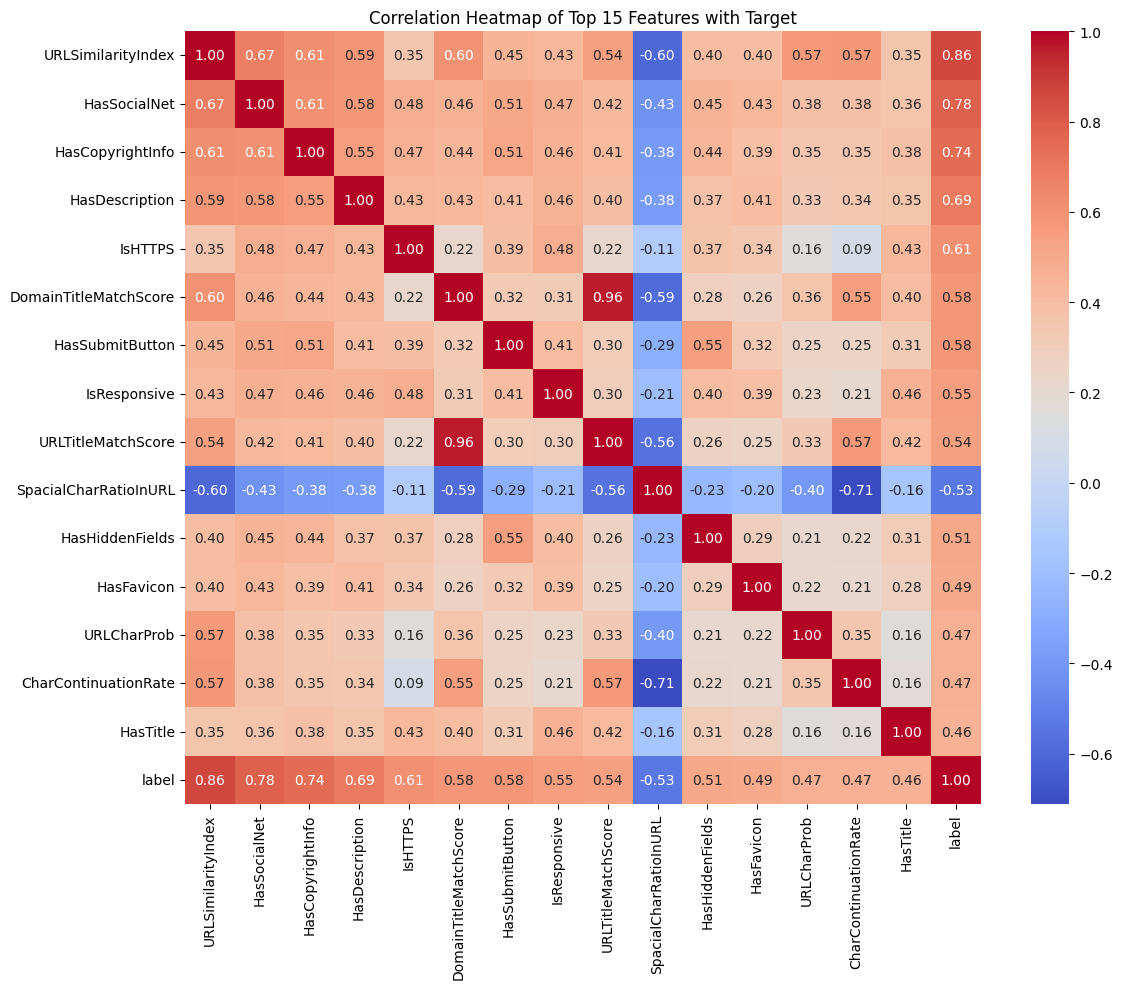

In [20]:
feature_corr_with_label = (
    df_clean.select_dtypes(include=["number"])
    .corr()["label"]
    .drop("label")
    .abs()
    .sort_values(ascending=False)
)

top_features = feature_corr_with_label.head(15).index

plt.figure(figsize=(12, 10))

sns.heatmap(
    df_clean[top_features.tolist() + ["label"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Top 15 Features with Target")
plt.tight_layout()
plt.show()

### Correlation Analysis — Key Findings

- URLSimilarityIndex shows a strong positive correlation with the target (r = 0.86).
- HasSocialNet and HasCopyrightInfo also show relatively strong positive associations with the target.
- SpacialCharRatioInURL shows a moderate negative correlation with the target (r = -0.53).
- URLTitleMatchScore and DomainTitleMatchScore are highly correlated with each other (r = 0.96), indicating potential feature redundancy.
- These findings will be provided to the ML team for consideration during subsequent feature selection and model development.

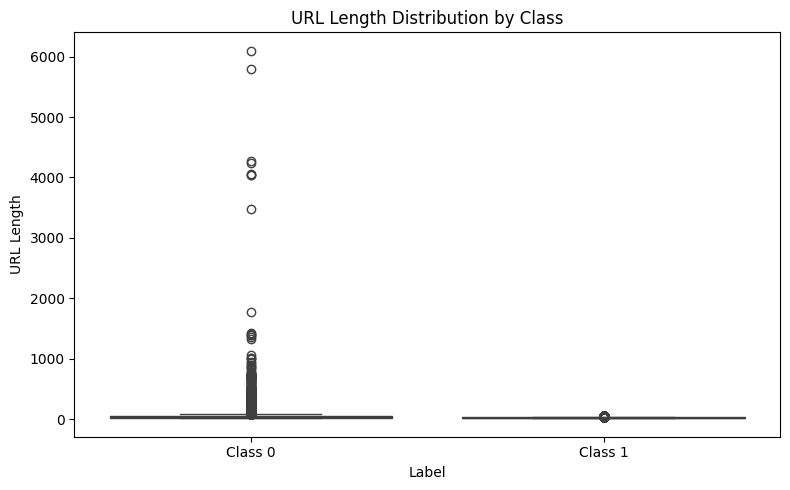

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="URLLength"
)

plt.title("URL Length Distribution by Class")
plt.xlabel("Label")
plt.ylabel("URL Length")

plt.xticks([0, 1], ["Class 0", "Class 1"])

plt.tight_layout()
plt.show()

In [22]:
df_clean.groupby("label")["URLLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,45.702845,61.252568,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


### URL Length Analysis — Key Findings

- Class 0 URLs have a higher median URL length (34 characters) compared with Class 1 URLs (26 characters).
- Class 0 shows substantially greater variability in URL length, with a standard deviation of approximately 61.25 compared with 4.82 for Class 1.
- Class 0 contains extreme URL-length values, reaching up to 6,097 characters, whereas Class 1 has a maximum observed length of 57 characters.
- The difference between the mean and median for Class 0 indicates the presence of extreme long-URL observations.
- These observations suggest that URL length and its variability may be useful characteristics for distinguishing the two classes and should be evaluated by the ML team during model development.

In [23]:
Q1 = df_clean["URLLength"].quantile(0.25)
Q3 = df_clean["URLLength"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["URLLength"] < lower_bound) |
    (df_clean["URLLength"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Outlier percentage:", round(len(outliers) / len(df_clean) * 100, 2), "%")

Q1: 23.0
Q3: 34.0
IQR: 11.0
Upper bound: 50.5
Number of outliers: 22362
Outlier percentage: 9.5 %


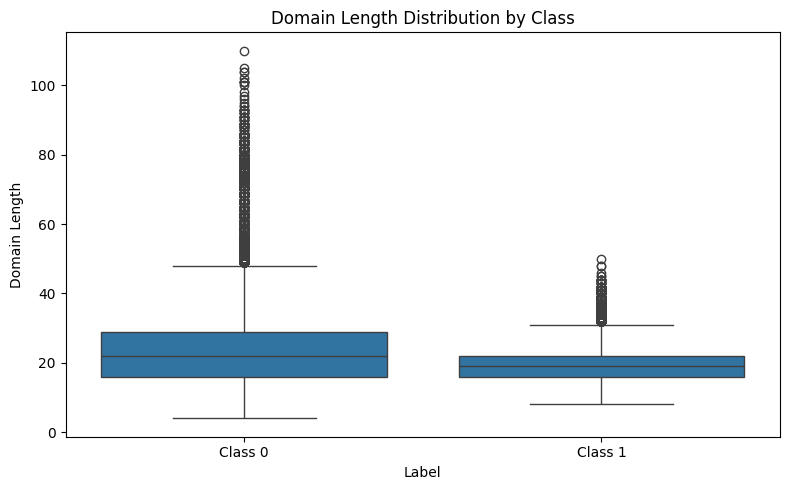

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="DomainLength"
)

plt.title("Domain Length Distribution by Class")
plt.xlabel("Label")
plt.ylabel("Domain Length")

plt.xticks([0, 1], ["Class 0", "Class 1"])

plt.tight_layout()
plt.show()

In [25]:
df_clean.groupby("label")["DomainLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,24.44415,12.181599,4.0,16.0,22.0,29.0,110.0
1,134850.0,19.22861,4.815612,8.0,16.0,19.0,22.0,50.0


### Domain Length Analysis — Key Findings

- Class 0 has a higher mean domain length (24.44 characters) than Class 1 (19.23 characters).
- The median domain length is also higher for Class 0 (22) compared with Class 1 (19).
- Class 0 shows substantially greater variability, with a standard deviation of 12.18 compared with 4.82 for Class 1.
- Class 0 contains more extreme domain-length observations, with a maximum of 110 characters compared with 50 characters for Class 1.
- The distribution suggests that domain length and its variability may provide useful information for distinguishing between the two classes and can be considered during subsequent model development.

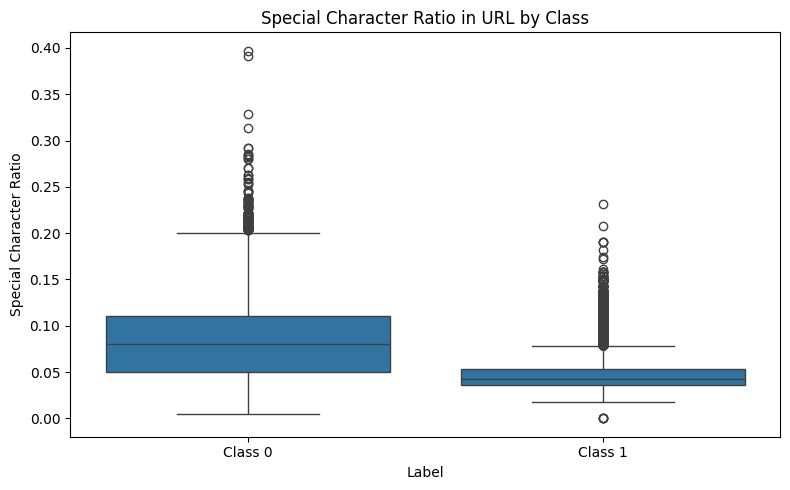

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="SpacialCharRatioInURL"
)

plt.title("Special Character Ratio in URL by Class")
plt.xlabel("Label")
plt.ylabel("Special Character Ratio")

plt.xticks([0, 1], ["Class 0", "Class 1"])

plt.tight_layout()
plt.show()

In [27]:
df_clean.groupby("label")["SpacialCharRatioInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.083229,0.035636,0.005,0.050,0.080,0.111,0.397
1,134850.0,0.048356,0.019030,0.000,0.036,0.042,0.053,0.231


### Special Character Ratio Analysis — Key Findings

- Class 0 has a higher mean special-character ratio (0.0832) compared with Class 1 (0.0484).
- The median special-character ratio is also higher for Class 0 (0.080) than Class 1 (0.042).
- Class 0 shows greater variability, with a standard deviation of 0.0356 compared with 0.0190 for Class 1.
- The distribution indicates that special-character composition differs considerably between the two classes.
- This observation is consistent with the negative correlation observed between SpacialCharRatioInURL and the target variable.
- The feature may therefore provide useful information for subsequent classification modelling.

In [28]:
pd.crosstab(
    df_clean["label"],
    df_clean["IsHTTPS"],
    normalize="index"
) * 100

IsHTTPS,0,1
label,,
0,50.877437,49.122563
1,0.000000,100.000000


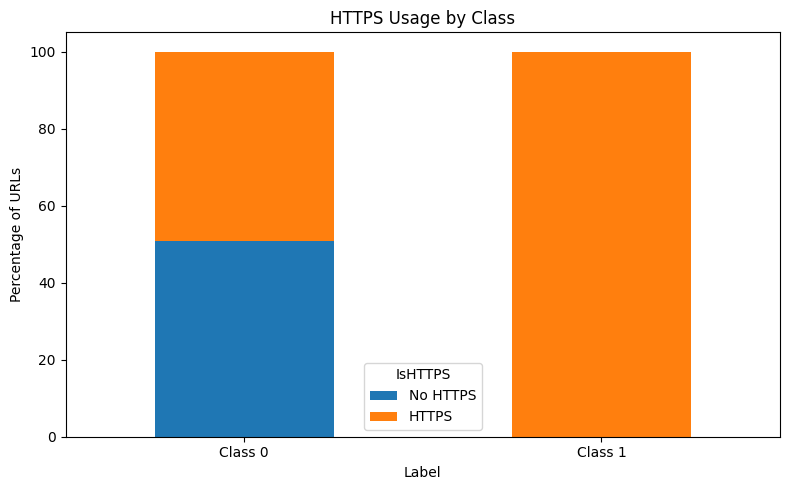

In [29]:
https_pct = (
    pd.crosstab(
        df_clean["label"],
        df_clean["IsHTTPS"],
        normalize="index"
    ) * 100
)

https_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("HTTPS Usage by Class")
plt.xlabel("Label")
plt.ylabel("Percentage of URLs")
plt.xticks([0, 1], ["Class 0", "Class 1"], rotation=0)
plt.legend(title="IsHTTPS", labels=["No HTTPS", "HTTPS"])

plt.tight_layout()
plt.show()

### HTTPS Analysis — Key Findings

- Class 0 contains approximately 49.12% HTTPS-enabled URLs and 50.88% URLs without HTTPS.
- Class 1 contains 100% HTTPS-enabled URLs.
- The strong separation between the two classes indicates that IsHTTPS is highly associated with the target variable in this dataset.
- HTTPS usage should not be interpreted as proof that a website is legitimate, since HTTPS can also be used by malicious websites.
- The ML team should investigate IsHTTPS carefully for potential dataset bias or leakage before relying heavily on this feature.

In [30]:
binary_features = [
    col for col in df_clean.columns
    if df_clean[col].nunique() == 2 and col!= "label"
]

binary_features

['IsDomainIP',
 'HasObfuscation',
 'IsHTTPS',
 'HasTitle',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo']

In [31]:
binary_percentage = (
    df_clean.groupby("label")[binary_features]
    .mean()
    .T * 100
)

binary_percentage.columns = ["Class 0", "Class 1"]

binary_percentage.sort_values("Class 1", ascending=False)

,Class 0,Class 1
IsHTTPS,49.122563,100.000000
HasTitle,67.723836,99.875417
IsResponsive,31.704138,85.436411
HasCopyrightInfo,5.724234,80.823878
HasSocialNet,0.508357,79.455692
HasDescription,4.406088,73.663330
HasSubmitButton,8.439117,66.088246
HasHiddenFields,9.303621,59.078235
HasFavicon,8.740549,56.702262
Robots,6.579785,41.673712


In [32]:
binary_diff = (
    binary_percentage["Class 1"] - binary_percentage["Class 0"]
).abs().sort_values(ascending=False)

top_binary_features = binary_diff.head(10).index

binary_percentage.loc[top_binary_features]

,Class 0,Class 1
HasSocialNet,0.508357,79.455692
HasCopyrightInfo,5.724234,80.823878
HasDescription,4.406088,73.663330
HasSubmitButton,8.439117,66.088246
IsResponsive,31.704138,85.436411
IsHTTPS,49.122563,100.000000
HasHiddenFields,9.303621,59.078235
HasFavicon,8.740549,56.702262
Robots,6.579785,41.673712
HasTitle,67.723836,99.875417


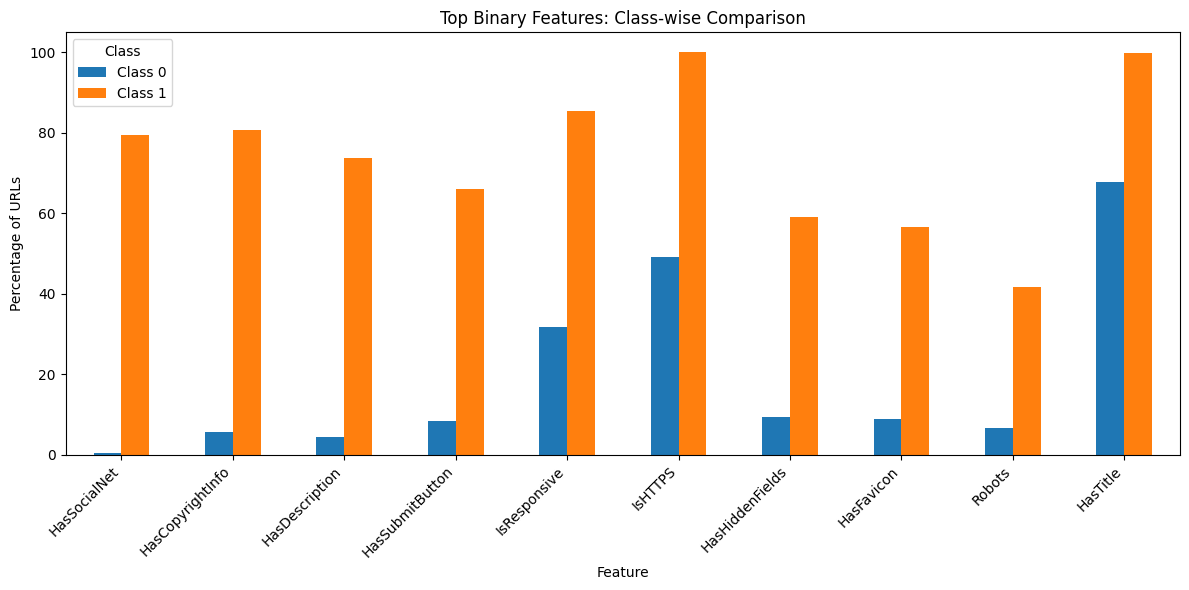

In [33]:
binary_percentage.loc[top_binary_features].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top Binary Features: Class-wise Comparison")
plt.xlabel("Feature")
plt.ylabel("Percentage of URLs")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

Binary Feature Analysis — Key Findings
1. IsHTTPS
Class 1: 100.00%
Class 0: 49.12%
HTTPS usage shows an extremely strong association with the target class.
ML consideration: This feature may be highly predictive, but the perfect separation for Class 1 should be investigated for possible dataset bias or feature leakage.
2. HasTitle
Class 1: 99.88%
Class 0: 67.72%
Most Class 1 URLs have an HTML page title, while a considerably smaller proportion of Class 0 URLs do.
ML consideration: Potentially useful classification feature.
3. IsResponsive
Class 1: 85.44%
Class 0: 31.70%
Responsive website design is considerably more common in Class 1.
ML consideration: Potentially useful feature for distinguishing the classes.
4. HasCopyrightInfo
Class 1: 80.82%
Class 0: 5.72%
Copyright information is substantially more prevalent in Class 1.
ML consideration: Strong candidate feature, although its unusually large class difference should be examined for dataset-specific effects.
5. HasSocialNet
Class 1: 79.46%
Class 0: 0.51%
Social-network indicators are almost absent in Class 0 but common in Class 1.
ML consideration: Highly discriminative feature; investigate potential dataset bias before relying heavily on it.
6. HasDescription
Class 1: 73.66%
Class 0: 4.41%
Meta/page descriptions are much more common in Class 1.
ML consideration: Potentially useful predictor.
7. HasSubmitButton
Class 1: 66.09%
Class 0: 8.44%
Submit buttons are substantially more common in Class 1.
ML consideration: Potentially useful feature, particularly when combined with other webpage characteristics.
8. HasHiddenFields
Class 1: 59.08%
Class 0: 9.30%
Hidden fields occur much more frequently in Class 1.
ML consideration: Potentially useful, but should be evaluated alongside other page-structure features.
9. HasFavicon
Class 1: 56.70%
Class 0: 8.74%
Favicons are considerably more common in Class 1.
ML consideration: Potentially useful website-structure feature.
10. Robots
Class 1: 41.67%
Class 0: 6.58%
robots.txt-related presence is more common in Class 1.
ML consideration: Could provide additional predictive information.
Features more common in Class 0
NoOfURLRedirect
Class 0: 15.17%
Class 1: 11.98%
Redirects are somewhat more prevalent in Class 0.
NoOfSelfRedirect
Class 0: 5.76%
Class 1: 2.71%
Self-redirects occur more frequently in Class 0.
HasObfuscation
Class 0: 0.48%
Class 1: 0%
Obfuscation is observed only in a small proportion of Class 0 records.
IsDomainIP
Class 0: 0.63%
Class 1: 0%
Direct IP-based domains occur only in a small proportion of Class 0 records

EDA indicates that several binary website characteristics show strong class separation, particularly HTTPS usage, copyright information, social-network presence, page descriptions, responsiveness, and title presence. These features should be evaluated as candidate predictors, while unusually strong separation—especially IsHTTPS—should be investigated for potential dataset bias or leakage.

In [63]:
domain_ip_pct = (
    pd.crosstab(
        df_clean["label"],
        df_clean["IsDomainIP"],
        normalize="index"
    ) * 100
)

domain_ip_pct.columns = ["Domain Name", "IP Address"]

domain_ip_pct

,Domain Name,IP Address
label,,
0,99.36729,0.63271
1,100.00000,0.00000


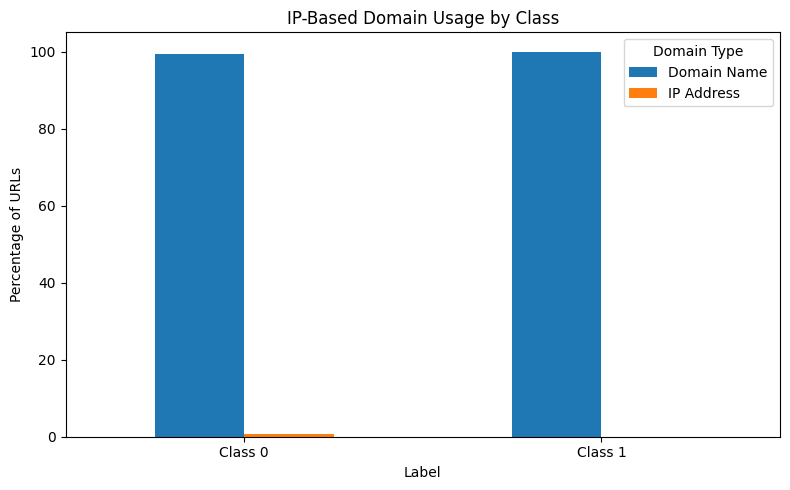

In [64]:
domain_ip_pct.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("IP-Based Domain Usage by Class")
plt.xlabel("Label")
plt.ylabel("Percentage of URLs")
plt.xticks([0, 1], ["Class 0", "Class 1"], rotation=0)
plt.legend(title="Domain Type")

plt.tight_layout()
plt.show()

### IsDomainIP — Key Findings

- 0.63% of Class 0 URLs use an IP address directly instead of a domain name, compared with 0% in Class 1.
- The feature shows a small but clear class-wise difference.
- However, IP-based URLs are very rare in the dataset, limiting the likely standalone predictive contribution of this feature.
- IsDomainIP can be retained as a candidate feature, but its actual importance should be validated through feature importance and model evaluation.

In [65]:
obfuscation_pct = (
    pd.crosstab(
        df_clean["label"],
        df_clean["HasObfuscation"],
        normalize="index"
    ) * 100
)

obfuscation_pct.columns = ["No Obfuscation", "Obfuscation"]

obfuscation_pct

,No Obfuscation,Obfuscation
label,,
0,99.519499,0.480501
1,100.000000,0.000000


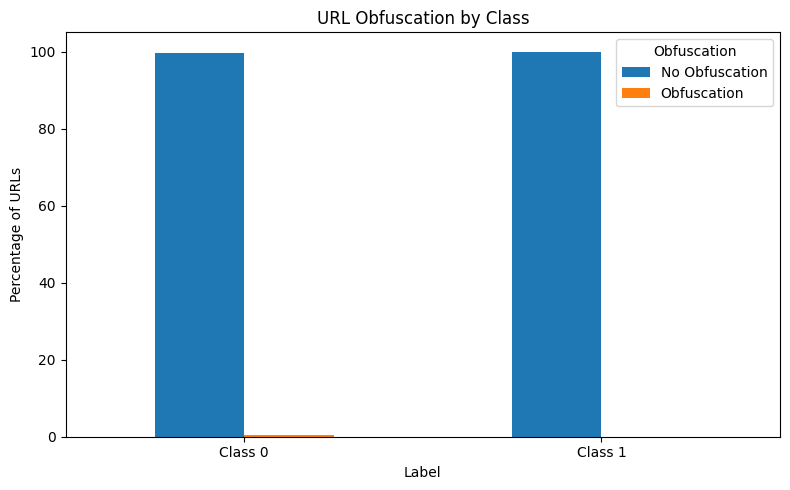

In [66]:
obfuscation_pct.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("URL Obfuscation by Class")
plt.xlabel("Label")
plt.ylabel("Percentage of URLs")
plt.xticks([0, 1], ["Class 0", "Class 1"], rotation=0)
plt.legend(title="Obfuscation")

plt.tight_layout()
plt.show()

### HasObfuscation — Key Findings

- Obfuscation is present in 0.48% of Class 0 URLs and 0% of Class 1 URLs.
- Although the feature shows complete separation for the observed Class 1 records, obfuscation is extremely rare in the overall dataset.
- Therefore, HasObfuscation may provide useful supporting information but is unlikely to be a strong standalone predictor.
- The feature should be evaluated through feature importance and model performance before deciding whether to retain or remove it.

In [67]:
df_clean.groupby("label")[["NoOfObfuscatedChar", "ObfuscationRatio"]].agg(
    ["mean", "median", "std", "min", "max"]
)

NoOfObfuscatedChar                           ObfuscationRatio         \
                    mean median       std min  max             mean median   
label                                                                        
0               0.058257    0.0  2.873274   0  447         0.000324    0.0   
1               0.000000    0.0  0.000000   0    0         0.000000    0.0   

                             
            std  min    max  
label                        
0      0.005838  0.0  0.348  
1      0.000000  0.0  0.000

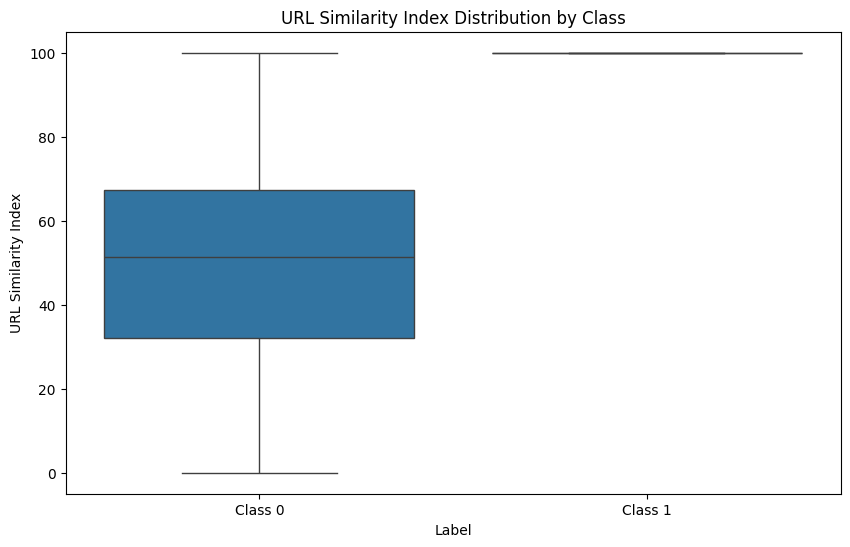

In [68]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="label",
    y="URLSimilarityIndex"
)

plt.title("URL Similarity Index Distribution by Class")
plt.xlabel("Label")
plt.ylabel("URL Similarity Index")
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.show()

In [69]:
df_clean.groupby("label")["URLSimilarityIndex"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,49.651466,22.578566,0.155574,32.120613,51.478561,67.307692,100.0
1,134850.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.0


URLSimilarityIndex – Key Findings

URLSimilarityIndex shows a strong difference between the two classes. Class 1 has a constant value of 100 across all observations, while Class 0 has a much wider distribution with a mean of approximately 49.65 and median of 51.48. This indicates that URLSimilarityIndex provides strong class-separating information and may be an important predictive feature. However, the constant value observed for Class 1 should be considered during feature selection and model evaluation.

In [70]:
df_clean.groupby("label")["URLTitleMatchScore"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,21.243217,40.539246,0.0,0.000000,0.0,1.351351,100.0
1,134850.0,75.270904,42.682798,0.0,77.777778,100.0,100.000000,100.0


URLTitleMatchScore – Key Findings

URLTitleMatchScore shows a strong difference between the two classes. Class 0 has a low mean of 21.24 and a median of 0, whereas Class 1 has a much higher mean of 75.27 and a median of 100. The majority of Class 1 observations have high URL-title matching scores, while Class 0 observations are predominantly associated with low scores. Therefore, URLTitleMatchScore appears to be a highly informative feature for class discrimination. However, its very high correlation (0.961) with DomainTitleMatchScore indicates potential feature redundancy, which should be considered during feature selection/model design.

In [71]:
df_clean.groupby("label")["URLLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,45.702845,61.252568,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


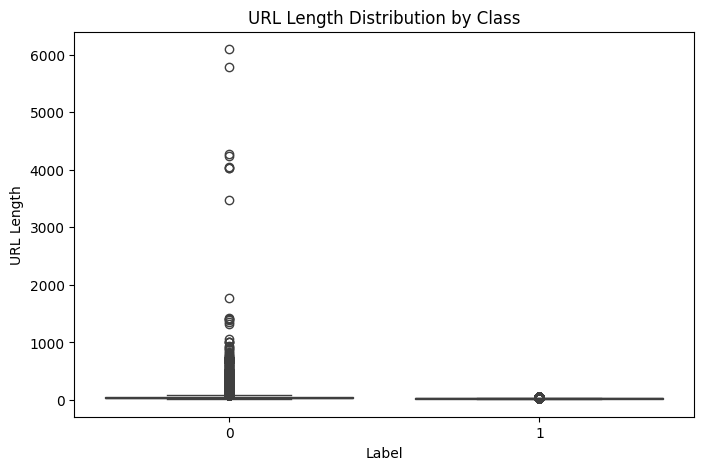

In [72]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="URLLength"
)

plt.title("URL Length Distribution by Class")
plt.xlabel("Label")
plt.ylabel("URL Length")
plt.show()

URLLength – Key Findings

URLLength shows a substantial difference between the two classes. Class 0 has a higher mean URL length (45.70) compared with Class 1 (26.23), along with a much wider distribution and several extreme outliers. Class 1 URLs are comparatively shorter and more concentrated. Therefore, URLLength can provide useful information for distinguishing between the classes. However, its strong correlation with NoOfLettersInURL (0.956) and NoOfDegitsInURL (0.836) indicates potential feature redundancy, which should be considered during feature selection.

In [73]:
df_clean.groupby("label")["NoOfLettersInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,28.088669,42.667153,0.0,13.0,20.0,31.0,5191.0
1,134850.0,12.933059,4.782969,1.0,9.0,13.0,16.0,44.0


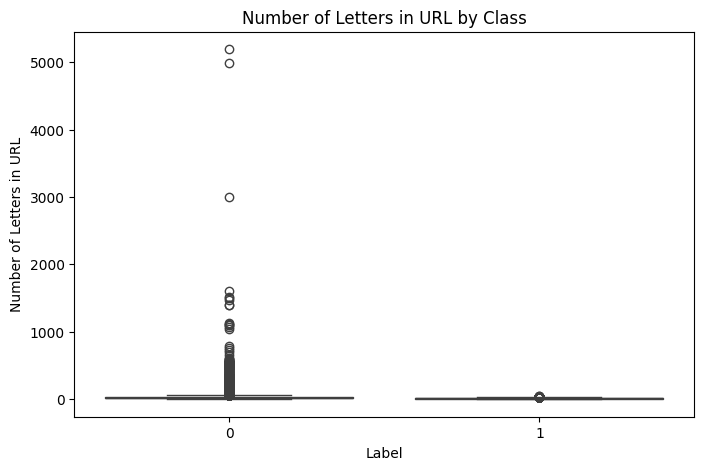

In [74]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfLettersInURL"
)

plt.title("Number of Letters in URL by Class")
plt.xlabel("Label")
plt.ylabel("Number of Letters in URL")
plt.show()

In [75]:
df_clean.groupby("label")["NoOfLettersInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,28.088669,42.667153,0.0,13.0,20.0,31.0,5191.0
1,134850.0,12.933059,4.782969,1.0,9.0,13.0,16.0,44.0


NoOfLettersInURL shows a clear distributional difference between the two classes. Class 0 URLs are generally longer and exhibit substantially greater variability, while Class 1 URLs remain relatively short and consistent. The presence of extreme values in Class 0 suggests that outlier handling or transformation may improve model robustness. Overall, the feature appears potentially useful for classification.

In [76]:
df_clean.columns.tolist()

['FILENAME',
 'URL',
 'URLLength',
 'Domain',
 'DomainLength',
 'IsDomainIP',
 'TLD',
 'URLSimilarityIndex',
 'CharContinuationRate',
 'TLDLegitimateProb',
 'URLCharProb',
 'TLDLength',
 'NoOfSubDomain',
 'HasObfuscation',
 'NoOfObfuscatedChar',
 'ObfuscationRatio',
 'NoOfLettersInURL',
 'LetterRatioInURL',
 'NoOfDegitsInURL',
 'DegitRatioInURL',
 'NoOfEqualsInURL',
 'NoOfQMarkInURL',
 'NoOfAmpersandInURL',
 'NoOfOtherSpecialCharsInURL',
 'SpacialCharRatioInURL',
 'IsHTTPS',
 'LineOfCode',
 'LargestLineLength',
 'HasTitle',
 'Title',
 'DomainTitleMatchScore',
 'URLTitleMatchScore',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'NoOfPopup',
 'NoOfiFrame',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo',
 'NoOfImage',
 'NoOfCSS',
 'NoOfJS',
 'NoOfSelfRef',
 'NoOfEmptyRef',
 'NoOfExternalRef',
 'label']

In [77]:
df_clean.groupby("label")["NoOfDegitsInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,4.324194,17.903642,0.0,0.0,0.0,5.0,2011.0
1,134850.0,0.050597,0.350326,0.0,0.0,0.0,0.0,8.0


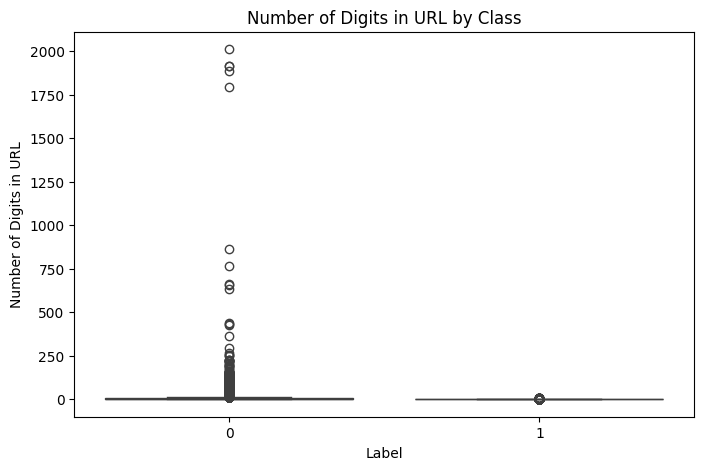

In [78]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfDegitsInURL"
)

plt.title("Number of Digits in URL by Class")
plt.xlabel("Label")
plt.ylabel("Number of Digits in URL")
plt.show()

In [79]:
df_clean.groupby("label")["DegitRatioInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.063933,0.096223,0.0,0.0,0.0,0.102,0.684
1,134850.0,0.002115,0.014682,0.0,0.0,0.0,0.000,0.348


DegitRatioInURL – Key Findings

Digit ratio is substantially higher in Class 0 (mean: 0.0639) than Class 1 (mean: 0.0021).
75% of Class 1 URLs have a digit ratio of 0, whereas Class 0 shows a 75th percentile of 0.102.
Class 0 also exhibits greater variability and a higher maximum value.
The feature shows strong potential for distinguishing between the two classes and should be retained for model evaluation.

In [80]:
df_clean.groupby("label")["NoOfEqualsInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.145941,1.42729,0.0,0.0,0.0,0.0,176.0
1,134850.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0


NoOfEqualsInURL – Key Findings

Class 1 URLs contain no = characters (mean, median, and maximum = 0).
Class 0 has a small but non-zero average (0.1459), with a maximum of 176.
Most Class 0 URLs also have zero occurrences, but a small number contain unusually high counts.
The feature provides strong class-separation potential but is highly skewed with extreme outliers.
Retain the feature and evaluate its contribution during model development.

In [81]:
df_clean.groupby("label")["NoOfQMarkInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.068892,0.291613,0.0,0.0,0.0,0.0,4.0
1,134850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


NoOfQMarkInURL – Key Findings

Class 1 URLs contain no ? characters (mean, median, and maximum = 0).
Class 0 has a non-zero mean of 0.0689, with a maximum of 4.
Most URLs in Class 0 also contain no ? characters, but a small subset contains one or more.
The feature shows clear class-level separation potential due to the complete absence of ? in Class 1.
The feature should be retained and evaluated during model development.

In [82]:
df_clean.groupby("label")["NoOfAmpersandInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.058725,1.280295,0.0,0.0,0.0,0.0,149.0
1,134850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


NoOfAmpersandInURL – Key Findings

Class 1 URLs contain no & characters (mean, median, and maximum = 0).
Class 0 has a small non-zero mean of 0.0587, with a maximum of 149.
Most Class 0 URLs also have zero occurrences, while a small subset contains unusually high counts.
The feature shows strong class-separation potential due to the complete absence of & in Class 1.
The distribution is highly skewed with extreme outliers; therefore, outlier handling or transformation may be considered during model development.

In [83]:
df_clean.groupby("label")["NoOfOtherSpecialCharsInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,3.799771,5.005659,1.0,2.0,3.0,5.0,499.0
1,134850.0,1.244835,0.503961,0.0,1.0,1.0,1.0,7.0


NoOfOtherSpecialCharsInURL – Key Findings

Class 0 has a substantially higher average number of other special characters (3.80) compared with Class 1 (1.24).
The median is also higher for Class 0 (3) than Class 1 (1).
Class 0 shows considerably greater variability, with a standard deviation of 5.01 compared with 0.50 for Class 1.
Extreme values are present in Class 0, with a maximum of 499 compared with only 7 in Class 1.
The feature indicates that Class 0 URLs generally contain more and more variable special-character usage.
The feature may provide useful predictive information, but its strong skewness and extreme outliers should be considered during model development.

In [84]:
df_clean.groupby("label")["SpacialCharRatioInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.083229,0.035636,0.005,0.050,0.080,0.111,0.397
1,134850.0,0.048356,0.019030,0.000,0.036,0.042,0.053,0.231


SpacialCharRatioInURL – Key Findings

Class 0 has a higher average special-character ratio (0.0832) compared with Class 1 (0.0484).
The median is also substantially higher for Class 0 (0.080) than Class 1 (0.042).
Class 0 shows greater variability in special-character usage, with a standard deviation of 0.0356 compared with 0.0190 for Class 1.
The results indicate that Class 0 URLs generally contain a higher proportion of special characters.
This finding is consistent with the higher NoOfOtherSpecialCharsInURL observed in Class 0.
The feature shows potential predictive value and should be evaluated during model development.

In [85]:
df_clean.groupby("label")["DomainLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,24.44415,12.181599,4.0,16.0,22.0,29.0,110.0
1,134850.0,19.22861,4.815612,8.0,16.0,19.0,22.0,50.0


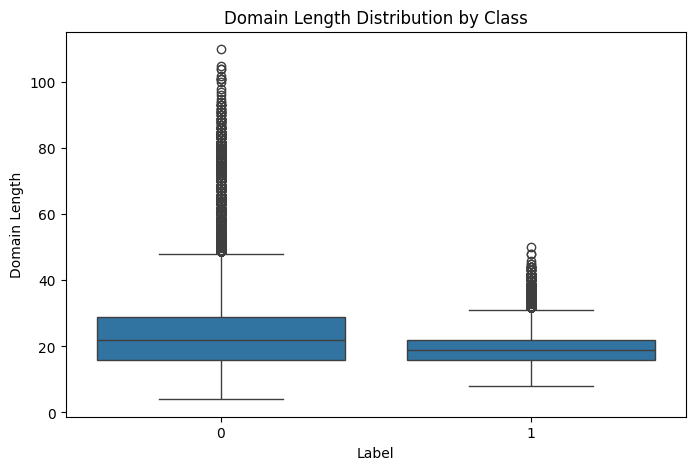

In [86]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="DomainLength"
)

plt.title("Domain Length Distribution by Class")
plt.xlabel("Label")
plt.ylabel("Domain Length")
plt.show()

DomainLength – Key Findings

Class 0 has a higher average domain length (24.44) than Class 1 (19.23).
The median domain length is also higher in Class 0 (22) compared with Class 1 (19).
Class 0 shows substantially greater variability, with a standard deviation of 12.18 compared with 4.82 for Class 1.
Class 0 contains longer extreme domain values, reaching a maximum of 110 compared with 50 for Class 1.
Overall, Class 0 domains tend to be longer and more variable than Class 1 domains.
The feature may provide useful predictive information, although its relationship with other URL-length features should be considered during feature selection.

In [87]:
df_clean.groupby("label")["TLDLegitimateProb"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.232167,0.254779,0.000000e+00,0.001502,0.018013,0.522907,0.522907
1,134850.0,0.281625,0.247132,6.000000e-07,0.018013,0.522907,0.522907,0.522907


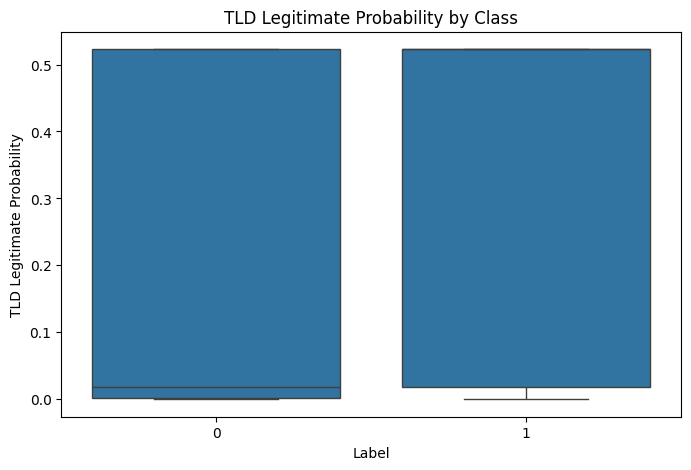

In [88]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="TLDLegitimateProb"
)

plt.title("TLD Legitimate Probability by Class")
plt.xlabel("Label")
plt.ylabel("TLD Legitimate Probability")
plt.show()

TLDLegitimateProb – Key Findings

Class 1 has a slightly higher mean TLD legitimacy probability (0.2816) than Class 0 (0.2322).
A substantial difference is observed in the median: 0.5229 for Class 1 compared with 0.0180 for Class 0.
The standard deviation is similar for both classes, indicating comparable overall variability.
Although the feature has a relatively weak Pearson correlation with the target (0.097), its class-wise distribution shows meaningful differences.
Therefore, correlation alone should not be used to eliminate this feature; its contribution should be evaluated during model training and feature selection.

In [89]:
df_clean.groupby("label")["URLCharProb"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.050005,0.011639,0.001083,0.042084,0.052030,0.058750,0.090681
1,134850.0,0.060050,0.007171,0.002259,0.056246,0.060628,0.064659,0.090824


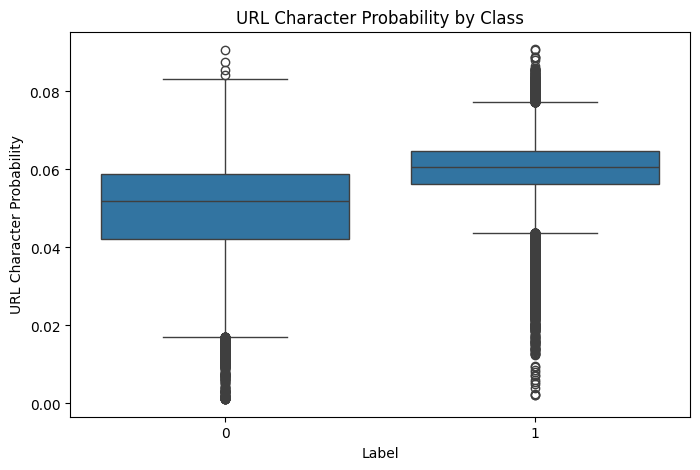

In [90]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="URLCharProb"
)

plt.title("URL Character Probability by Class")
plt.xlabel("Label")
plt.ylabel("URL Character Probability")
plt.show()

URLCharProb – Key Findings

Class 1 has a higher average URL character probability (0.0601) compared with Class 0 (0.0500).
The median is also higher for Class 1 (0.0606 vs. 0.0520).
Class 1 shows lower variability, with a standard deviation of 0.0072 compared with 0.0116 for Class 0.
The distributions suggest that Class 1 URLs generally have higher character-probability values.
The feature has a moderate positive correlation with the target (~0.47), supporting its potential predictive usefulness.
Therefore, URLCharProb should be retained for model evaluation.

In [91]:
df_clean.groupby("label")["CharContinuationRate"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.728818,0.243891,0.037736,0.545455,0.727273,1.0,1.0
1,134850.0,0.933176,0.139818,0.000000,1.000000,1.000000,1.0,1.0


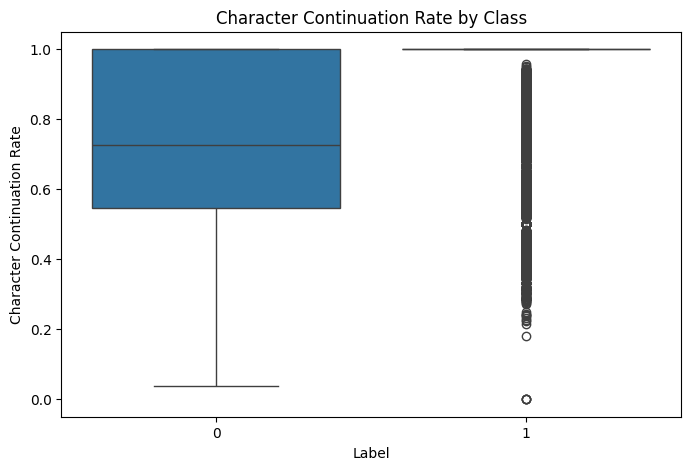

In [92]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="CharContinuationRate"
)

plt.title("Character Continuation Rate by Class")
plt.xlabel("Label")
plt.ylabel("Character Continuation Rate")
plt.show()

CharContinuationRate – Key Findings

Class 1 has a substantially higher mean character continuation rate (0.9332) compared with Class 0 (0.7288).
The median and first quartile for Class 1 are both 1.0, indicating that at least 75% of Class 1 observations have a continuation rate of 1.0.
Class 0 shows greater variability, with a standard deviation of 0.2439 compared with 0.1398 for Class 1.
Overall, Class 1 URLs demonstrate more consistent character continuation patterns.
The feature has a moderate positive correlation with the target (~0.467), indicating potential predictive value.
The feature should therefore be retained for model evaluation.

In [93]:
df_clean.groupby("label")["NoOfSubDomain"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,1.169379,0.791096,0.0,1.0,1.0,1.0,10.0
1,134850.0,1.161661,0.404076,1.0,1.0,1.0,1.0,4.0


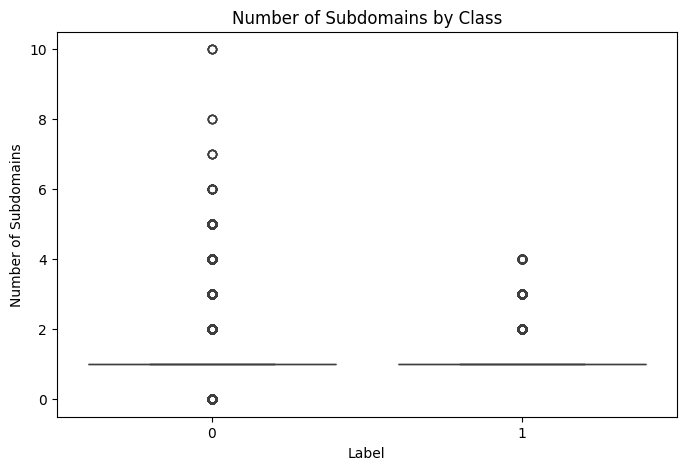

In [94]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfSubDomain"
)

plt.title("Number of Subdomains by Class")
plt.xlabel("Label")
plt.ylabel("Number of Subdomains")
plt.show()

NoOfSubDomain – Key Findings

Both classes have very similar average numbers of subdomains (1.169 for Class 0 and 1.162 for Class 1).
The median is 1 for both classes, indicating similar central tendency.
Class 0 has greater variability and a higher maximum value (10 vs. 4).
Overall, there is little difference in the central distribution between the two classes.
This is consistent with the near-zero correlation with the target (~-0.006).
Therefore, NoOfSubDomain appears to be a relatively weak individual predictor and can be evaluated for removal during feature selection.

In [95]:
df_clean.groupby("label")["TLDLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,2.819121,0.691600,2.0,2.0,3.0,3.0,13.0
1,134850.0,2.723382,0.516913,2.0,2.0,3.0,3.0,13.0


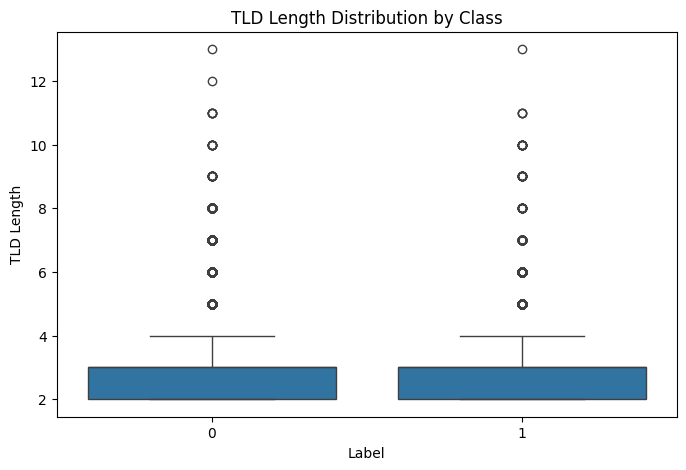

In [96]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="TLDLength"
)

plt.title("TLD Length Distribution by Class")
plt.xlabel("Label")
plt.ylabel("TLD Length")
plt.show()

TLDLength – Key Findings

The mean TLD length is very similar between Class 0 (2.819) and Class 1 (2.723).
Both classes have the same median (3), first quartile (2), third quartile (3), and maximum value (13).
Class 0 shows slightly greater variability than Class 1.
Overall, there is very little difference in TLD length between the two classes.
This is consistent with the weak correlation with the target (~-0.079).
Therefore, TLDLength appears to be a relatively weak individual predictor and can be considered for removal during feature selection.

In [97]:
df_clean.groupby("label")["NoOfURLRedirect"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.151661,0.358694,0.0,0.0,0.0,0.0,1.0
1,134850.0,0.119770,0.324694,0.0,0.0,0.0,0.0,1.0


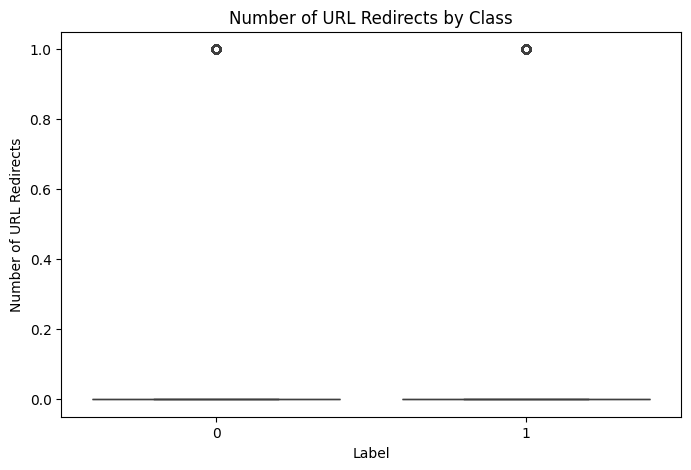

In [98]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfURLRedirect"
)

plt.title("Number of URL Redirects by Class")
plt.xlabel("Label")
plt.ylabel("Number of URL Redirects")
plt.show()

NoOfURLRedirect – Key Findings

Both classes have a median of 0 URL redirects, with 75% of observations having no redirects.
Class 0 has a slightly higher mean (0.152) than Class 1 (0.120).
Both classes have the same maximum value of 1.
Overall, the distributions are very similar, indicating limited class-separation ability.
This is consistent with the weak correlation with the target (~-0.046).
Therefore, NoOfURLRedirect appears to be a weak individual predictor and can be considered for removal during feature selection.

In [99]:
df_clean.groupby("label")["NoOfSelfRedirect"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.057591,0.232969,0.0,0.0,0.0,0.0,1.0
1,134850.0,0.027126,0.162452,0.0,0.0,0.0,0.0,1.0


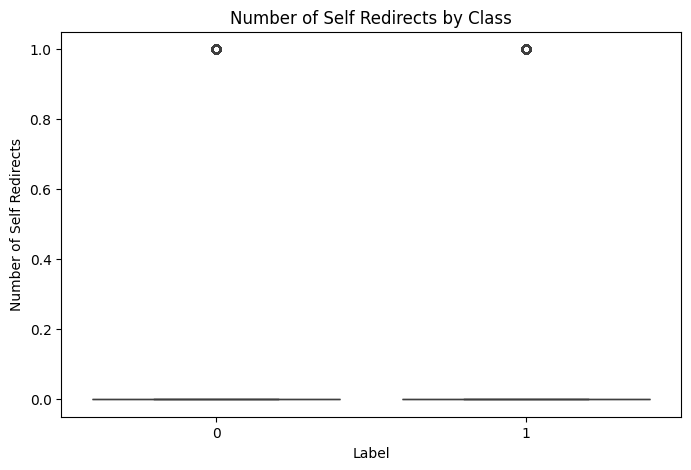

In [100]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfSelfRedirect"
)

plt.title("Number of Self Redirects by Class")
plt.xlabel("Label")
plt.ylabel("Number of Self Redirects")
plt.show()

NoOfSelfRedirect – Key Findings

Both classes have a median of 0, with 75% of observations having no self-redirects.
Class 0 has a slightly higher mean (0.0576) compared with Class 1 (0.0271).
Both classes have the same maximum value of 1.
Overall, the class distributions are very similar, indicating limited discriminative power.
This is consistent with the weak correlation with the target (~-0.077).
Therefore, NoOfSelfRedirect appears to be a weak individual predictor and can be considered for removal during feature selection.

In [45]:
df_clean.groupby("label")["LineOfCode"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,65.606257,196.119589,2.0,2.0,12.0,90.0,29687.0
1,134850.0,1947.491680,4348.195220,102.0,613.0,1105.0,2088.0,442666.0


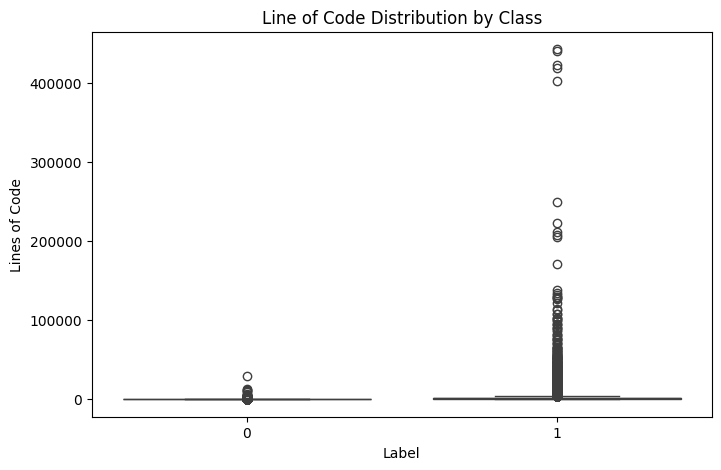

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="LineOfCode"
)

plt.title("Line of Code Distribution by Class")
plt.xlabel("Label")
plt.ylabel("Lines of Code")
plt.show()

LineOfCode – Key Findings

Class 1 has a substantially higher average number of lines of code (1947.49) compared with Class 0 (65.61).
The median also shows a very large difference: 1105 for Class 1 versus 12 for Class 0.
Class 1 has considerably greater variability, with a standard deviation of 4348.20 compared with 196.12 for Class 0.
The maximum value is also much higher for Class 1 (442,666 vs. 29,687).
Overall, Class 1 webpages demonstrate substantially greater HTML/code volume and structural complexity.
The feature appears highly informative for class discrimination, but its extreme right-skewness and outliers should be considered during model development.

In [47]:
df_clean.groupby("label")["LargestLineLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,19711.915589,227212.924306,22.0,58.0,137.0,869.0,13975732.0
1,134850.0,7375.919555,12778.201716,84.0,875.0,3066.0,9381.0,636010.0


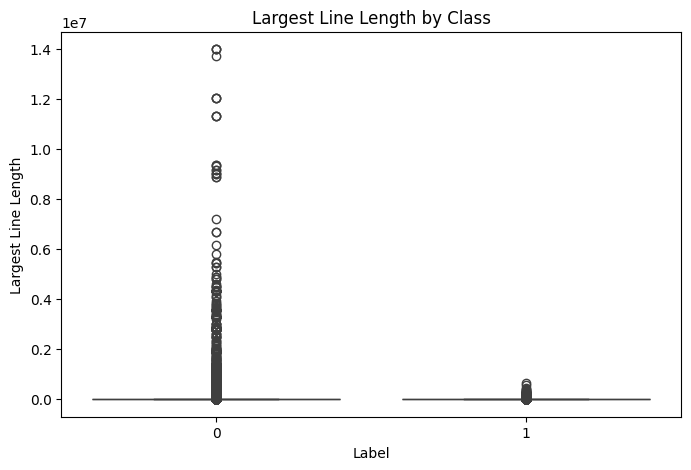

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="LargestLineLength"
)

plt.title("Largest Line Length by Class")
plt.xlabel("Label")
plt.ylabel("Largest Line Length")
plt.show()

LargestLineLength – Key Findings

The mean is higher for Class 0 (19,711.92) than Class 1 (7,375.92), but this is strongly influenced by extreme Class 0 outliers.
The median provides a more representative comparison: 137 for Class 0 versus 3,066 for Class 1.
Class 1 also has substantially higher Q1 and Q3 values, indicating that typical Class 1 webpages contain longer individual code lines.
Class 0 contains an extreme maximum value of 13,975,732, resulting in very high variability.
Therefore, median and percentile statistics are more informative than the mean for this feature.
Outlier handling or a logarithmic transformation should be considered during model development.

In [49]:
df_clean.groupby("label")["NoOfImage"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.864206,3.296758,0.0,0.0,0.0,0.0,158.0
1,134850.0,44.946600,100.930539,0.0,13.0,25.0,47.0,8956.0


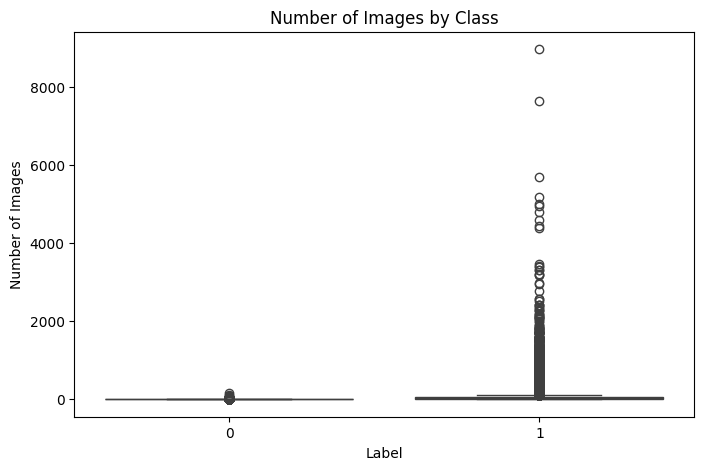

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfImage"
)

plt.title("Number of Images by Class")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.show()

NoOfImage – Key Findings

Class 0 has a very low average number of images (0.86), while Class 1 has a much higher average (44.95).
The median is 0 for Class 0 and 25 for Class 1, indicating a substantial difference in typical image usage.
Class 1 also has considerably higher quartile values, suggesting that webpages in this class generally contain more images.
Class 1 shows much greater variability, with a standard deviation of 100.93.
The maximum number of images is 8,956 for Class 1 compared with 158 for Class 0.
Overall, NoOfImage appears to be a strong discriminative feature, although extreme values/outliers should be considered during model development.

In [51]:
df_clean.groupby("label")["NoOfCSS"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.43844,1.439692,0.0,0.0,0.0,0.0,131.0
1,134850.0,10.74482,98.760825,0.0,3.0,6.0,13.0,35820.0


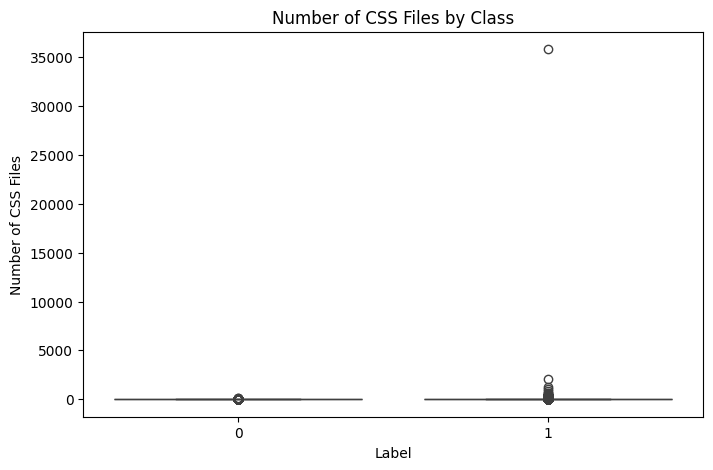

In [52]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfCSS"
)

plt.title("Number of CSS Files by Class")
plt.xlabel("Label")
plt.ylabel("Number of CSS Files")
plt.show()

NoOfCSS – Key Findings

Class 1 has a substantially higher average number of CSS resources (10.74) compared with Class 0 (0.44).
The median is 6 for Class 1 versus 0 for Class 0, indicating considerably greater CSS usage in Class 1.
Class 1 also has higher quartile values (Q1 = 3, Q3 = 13), showing a generally higher CSS-resource count.
Class 1 has very high variability, with a standard deviation of 98.76 and a maximum value of 35,820.
Overall, NoOfCSS shows clear class-level differences and may provide useful predictive information.
Due to extreme outliers, robust scaling or logarithmic transformation may be considered during model development.

In [53]:
df_clean.groupby("label")["NoOfJS"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.887992,3.365560,0.0,0.0,0.0,0.0,102.0
1,134850.0,17.732532,27.213939,0.0,8.0,14.0,23.0,6957.0


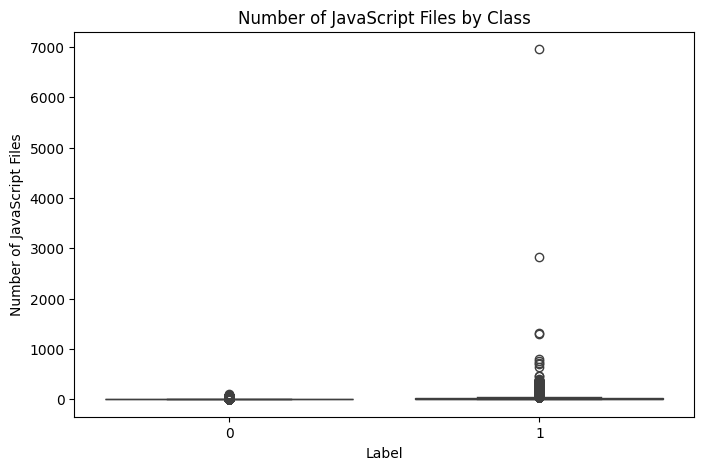

In [54]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfJS"
)

plt.title("Number of JavaScript Files by Class")
plt.xlabel("Label")
plt.ylabel("Number of JavaScript Files")
plt.show()

NoOfJS – Key Findings

Class 1 has a substantially higher average JavaScript count (17.73) compared with Class 0 (0.89).
The median is 8 for Class 1 versus 0 for Class 0, indicating significantly greater JavaScript usage in Class 1.
Class 1 also has a higher third quartile (14), showing a generally greater JavaScript resource count.
Class 1 has greater variability, with a standard deviation of 27.21 compared with 3.37 for Class 0.
The maximum value is 6,957 for Class 1 compared with 102 for Class 0.
Overall, NoOfJS shows clear class-level separation and may provide useful predictive information.
Extreme values should be considered during model development, potentially using outlier handling or logarithmic transformation.

In [55]:
df_clean.groupby("label")["NoOfSelfRef"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.496180,3.171505,0.0,0.0,0.0,0.0,120.0
1,134850.0,113.410241,221.635349,0.0,35.0,76.0,140.0,27397.0


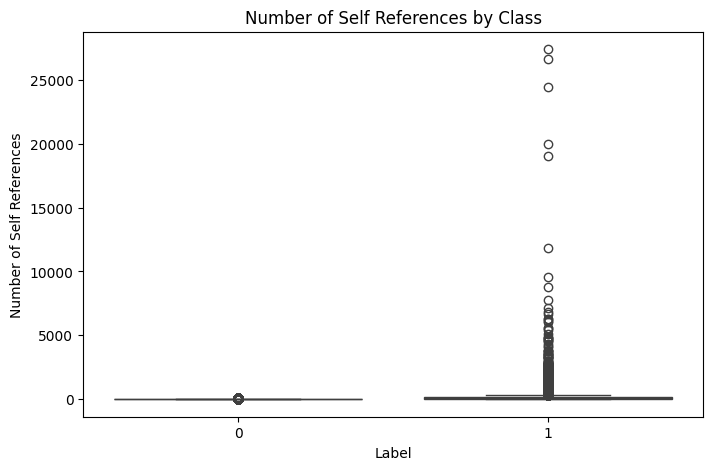

In [56]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfSelfRef"
)

plt.title("Number of Self References by Class")
plt.xlabel("Label")
plt.ylabel("Number of Self References")
plt.show()

NoOfSelfRef – Key Findings

Class 1 has a substantially higher average number of self-references (113.41) compared with Class 0 (0.50).
The median is 76 for Class 1 versus 0 for Class 0, indicating a major difference in typical self-reference behaviour.
Class 1 also has a much higher third quartile (140), while Class 0 remains concentrated at zero.
Class 1 shows significantly greater variability, with a standard deviation of 221.64.
The maximum value is 27,397 for Class 1 compared with 120 for Class 0.
Overall, NoOfSelfRef demonstrates strong class-level separation and appears to be a potentially important predictive feature.
The feature contains extreme values, so outlier handling or logarithmic transformation should be considered during model development.

In [57]:
df_clean.groupby("label")["NoOfEmptyRef"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.149234,1.778205,0.0,0.0,0.0,0.0,91.0
1,134850.0,4.044887,23.136610,0.0,0.0,1.0,3.0,4887.0


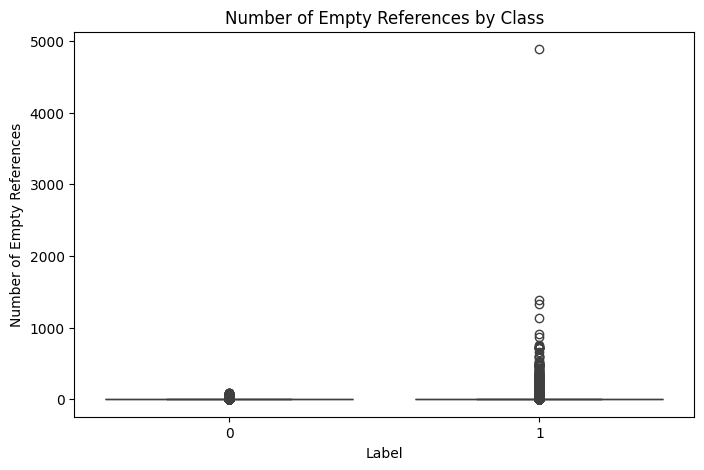

In [58]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfEmptyRef"
)

plt.title("Number of Empty References by Class")
plt.xlabel("Label")
plt.ylabel("Number of Empty References")
plt.show()

NoOfEmptyRef – Key Findings

Class 1 has a considerably higher average number of empty references (4.04) compared with Class 0 (0.15).
The median is 0 for both classes, indicating that many observations contain no empty references.
However, Class 1 has a higher third quartile (1 vs. 0), suggesting greater occurrence of empty references.
Class 1 shows substantially higher variability, with a standard deviation of 23.14 compared with 1.78.
The maximum value is also much higher for Class 1 (4,887 vs. 91).
Overall, Class 1 demonstrates greater empty-reference usage, although the relatively weak target correlation (~0.109) suggests limited standalone predictive strength.
Extreme values should be considered during model development.

In [59]:
df_clean.groupby("label")["NoOfExternalRef"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,1.126960,3.208068,0.0,0.0,0.0,1.0,368.0
1,134850.0,85.294601,205.669475,0.0,17.0,46.0,106.0,27516.0


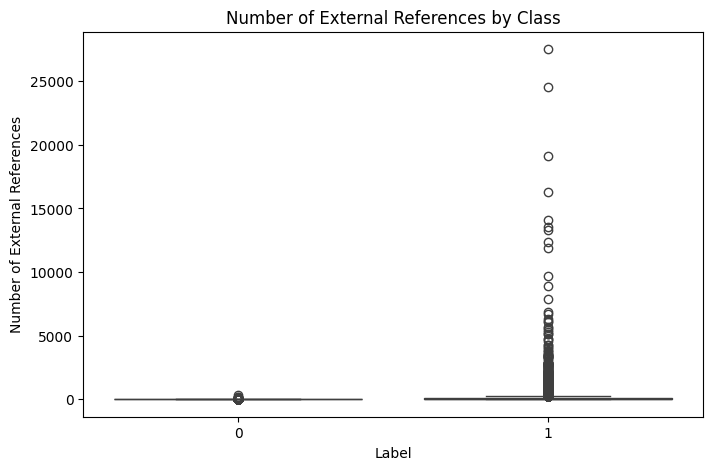

In [60]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfExternalRef"
)

plt.title("Number of External References by Class")
plt.xlabel("Label")
plt.ylabel("Number of External References")
plt.show()

NoOfExternalRef – Key Findings

Class 1 has a substantially higher average number of external references (85.29) compared with Class 0 (1.13).
The median is 17 for Class 1 versus 0 for Class 0, indicating a significant difference in typical external-reference usage.
Class 1 also has a much higher third quartile (46 vs. 1).
Class 1 demonstrates considerably greater variability, with a standard deviation of 205.67.
The maximum value is 27,516 for Class 1 compared with 368 for Class 0.
Overall, NoOfExternalRef shows strong class-level separation and may provide useful predictive information.
Extreme values should be considered during model development, potentially using outlier handling or logarithmic transformation.

In [61]:
df_clean.groupby("label")["NoOfEqualsInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.145941,1.42729,0.0,0.0,0.0,0.0,176.0
1,134850.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0


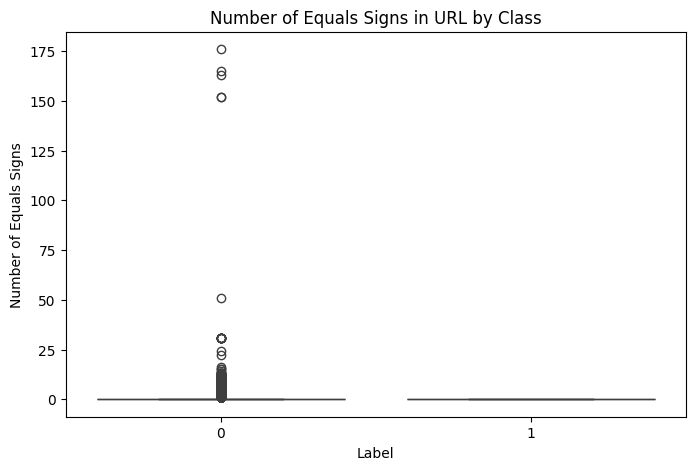

In [62]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfEqualsInURL"
)

plt.title("Number of Equals Signs in URL by Class")
plt.xlabel("Label")
plt.ylabel("Number of Equals Signs")
plt.show()

In [101]:
df_clean.groupby("label")["NoOfQMarkInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.068892,0.291613,0.0,0.0,0.0,0.0,4.0
1,134850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


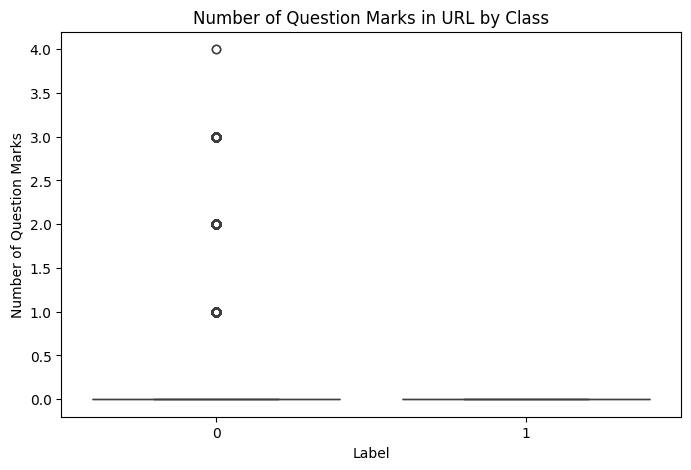

In [102]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfQMarkInURL"
)

plt.title("Number of Question Marks in URL by Class")
plt.xlabel("Label")
plt.ylabel("Number of Question Marks")
plt.show()

NoOfQMarkInURL – Key Findings

Class 1 contains no question marks in the URL, with mean and standard deviation both equal to 0.
Class 0 has a small average value of 0.0689, with a maximum of 4 question marks.
The median and third quartile are 0 for both classes, indicating that the feature is highly sparse.
Despite its sparse distribution, the feature provides some class-level separation because non-zero values occur only in Class 0.
Its weak-to-moderate negative correlation with the target (~-0.176) supports this observation.
The feature can be retained initially, with its final usefulness determined during model-based feature selection.

In [103]:
df_clean.groupby("label")["NoOfAmpersandInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.058725,1.280295,0.0,0.0,0.0,0.0,149.0
1,134850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


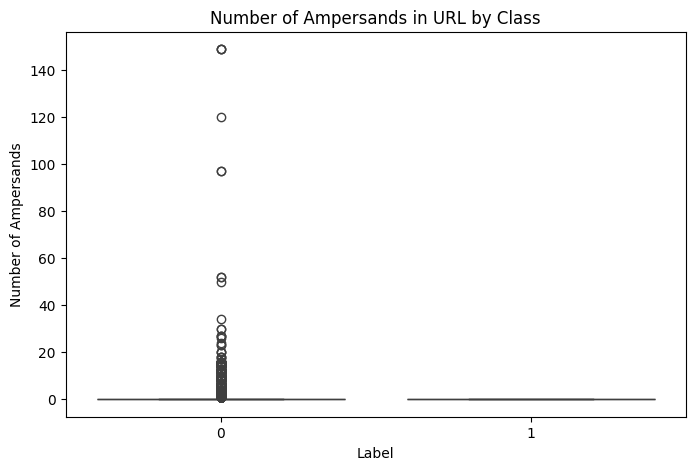

In [104]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfAmpersandInURL"
)

plt.title("Number of Ampersands in URL by Class")
plt.xlabel("Label")
plt.ylabel("Number of Ampersands")
plt.show()

NoOfAmpersandInURL – Key Findings

Class 1 contains no ampersands in the URL, while Class 0 has a small number of non-zero observations.
The feature is highly sparse, with median and third quartile equal to zero for both classes.
Class 0 has a higher mean (0.0587) and shows extreme values up to 149.
The high standard deviation in Class 0 is primarily influenced by these extreme observations.
Despite the near-zero Pearson correlation with the target (~-0.035), the absence of non-zero values in Class 1 provides some class-specific separation.
The feature's final usefulness should therefore be determined through model-based feature importance rather than correlation alone.

In [105]:
df_clean.groupby("label")["NoOfOtherSpecialCharsInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,3.799771,5.005659,1.0,2.0,3.0,5.0,499.0
1,134850.0,1.244835,0.503961,0.0,1.0,1.0,1.0,7.0


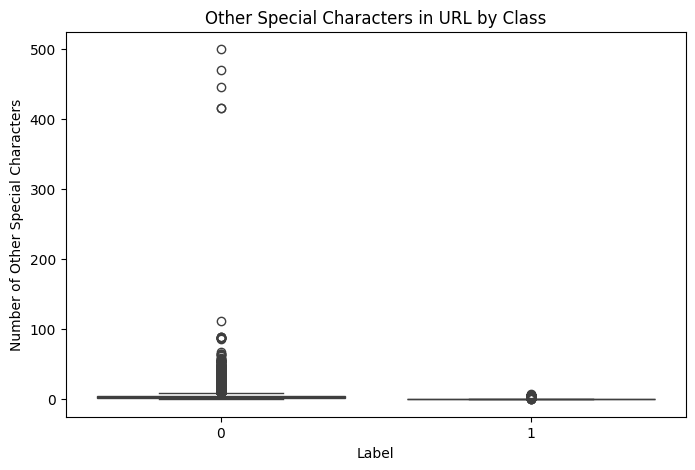

In [106]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfOtherSpecialCharsInURL"
)

plt.title("Other Special Characters in URL by Class")
plt.xlabel("Label")
plt.ylabel("Number of Other Special Characters")
plt.show()

NoOfOtherSpecialCharsInURL – Key Findings

Class 0 has a substantially higher average number of other special characters (3.80) compared with Class 1 (1.24).
The median is also higher for Class 0 (3 vs. 1), indicating greater special-character usage in typical Class 0 URLs.
Class 0 has greater variability, with a standard deviation of 5.01 compared with 0.50 for Class 1.
The maximum value is 499 for Class 0 compared with only 7 for Class 1, indicating the presence of extreme outliers.
The feature has a moderate negative correlation with the target (~-0.358), supporting its potential predictive usefulness.
Overall, NoOfOtherSpecialCharsInURL appears to be a useful URL-complexity feature, although extreme values should be handled appropriately during model development

In [107]:
df_clean.groupby("label")["SpacialCharRatioInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.083229,0.035636,0.005,0.050,0.080,0.111,0.397
1,134850.0,0.048356,0.019030,0.000,0.036,0.042,0.053,0.231


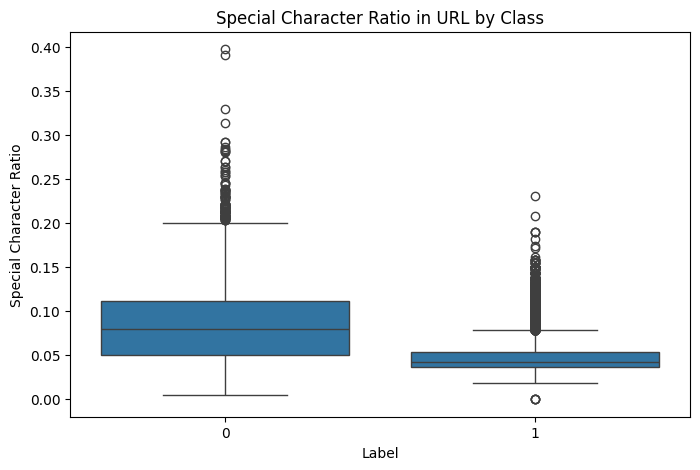

In [108]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="SpacialCharRatioInURL"
)

plt.title("Special Character Ratio in URL by Class")
plt.xlabel("Label")
plt.ylabel("Special Character Ratio")
plt.show()

SpacialCharRatioInURL – Key Findings

Class 0 has a higher average special-character ratio (0.0832) compared with Class 1 (0.0484).
The median is also substantially higher for Class 0 (0.080 vs. 0.042).
Class 0 has consistently higher Q1, median, and Q3 values, indicating greater special-character density across the distribution.
The maximum value is 0.397 for Class 0 compared with 0.231 for Class 1.
The feature has a relatively strong negative correlation with the target (~-0.533), indicating substantial class-level association.
Overall, SpacialCharRatioInURL appears to be an important URL-based feature and should be considered during model development.

In [109]:
df_clean.groupby("label")["DegitRatioInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.063933,0.096223,0.0,0.0,0.0,0.102,0.684
1,134850.0,0.002115,0.014682,0.0,0.0,0.0,0.000,0.348


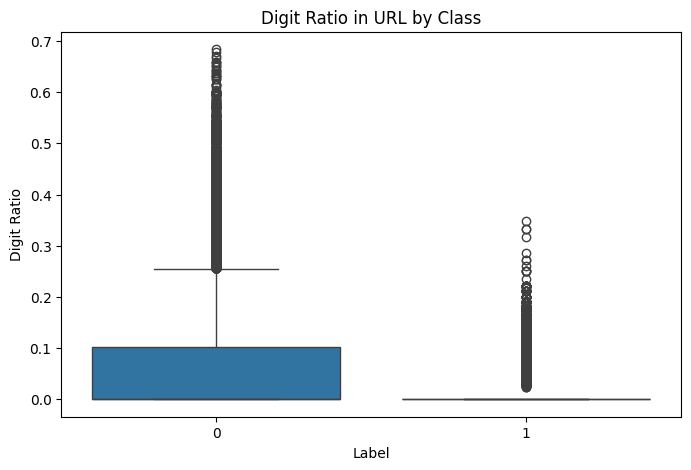

In [110]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="DegitRatioInURL"
)

plt.title("Digit Ratio in URL by Class")
plt.xlabel("Label")
plt.ylabel("Digit Ratio")
plt.show()

DegitRatioInURL – Key Findings

Class 0 has a substantially higher average digit ratio (0.0639) compared with Class 1 (0.0021).
The median is 0 for both classes, indicating that at least half of the URLs contain no digits.
However, the third quartile is 0.102 for Class 0 compared with 0 for Class 1, showing greater digit usage in the upper portion of Class 0.
Class 0 also shows considerably higher variability and a higher maximum value (0.684 vs. 0.348).
The feature has a relatively strong negative correlation with the target (~-0.432).
Overall, DegitRatioInURL appears to be a potentially important URL-based feature for classification.

In [111]:
df_clean.groupby("label")["LetterRatioInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,0.568128,0.136460,0.000,0.478,0.577,0.675,0.926
1,134850.0,0.476705,0.095166,0.056,0.409,0.480,0.552,0.772


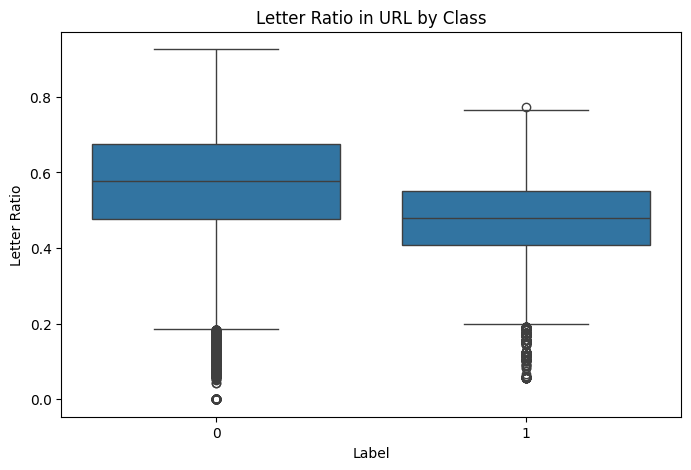

In [112]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="LetterRatioInURL"
)

plt.title("Letter Ratio in URL by Class")
plt.xlabel("Label")
plt.ylabel("Letter Ratio")
plt.show()

LetterRatioInURL – Key Findings

Class 0 has a higher average letter ratio (0.568) compared with Class 1 (0.477).
The median is also higher for Class 0 (0.577 vs. 0.480), indicating greater letter density in typical Class 0 URLs.
Class 0 consistently shows higher Q1, median, and Q3 values.
Class 0 has greater variability and a higher maximum value (0.926 vs. 0.772).
The feature has a moderate negative correlation with the target (~-0.367).
Overall, LetterRatioInURL provides useful information about URL character composition and should be evaluated during model feature selection.

In [113]:
df_clean.groupby("label")["NoOfLettersInURL"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,28.088669,42.667153,0.0,13.0,20.0,31.0,5191.0
1,134850.0,12.933059,4.782969,1.0,9.0,13.0,16.0,44.0


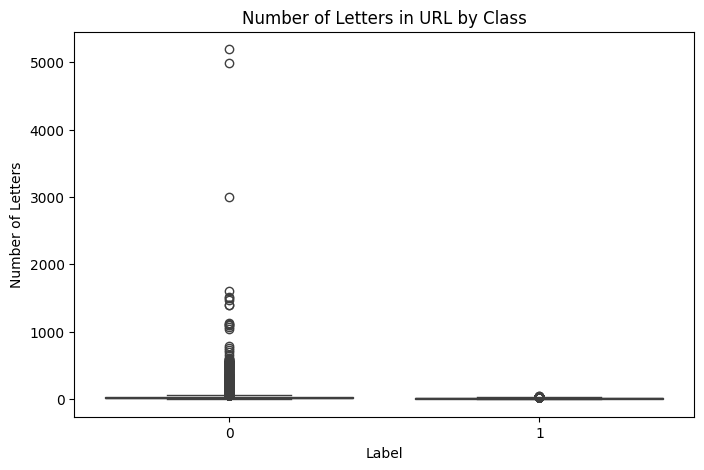

In [114]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="NoOfLettersInURL"
)

plt.title("Number of Letters in URL by Class")
plt.xlabel("Label")
plt.ylabel("Number of Letters")
plt.show()

NoOfLettersInURL – Key Findings

Class 0 has a substantially higher average number of letters in the URL (28.09) compared with Class 1 (12.93).
The median is also higher for Class 0 (20 vs. 13), indicating greater letter usage in typical Class 0 URLs.
Class 0 has a higher Q3 (31 vs. 16), showing greater letter counts across the upper part of the distribution.
Class 0 contains extreme outliers, with a maximum of 5,191 compared with 44 for Class 1, resulting in much higher variability.
The feature has a strong positive correlation with URLLength (~0.956), indicating substantial redundancy.
Overall, NoOfLettersInURL shows clear class-level differences but should be evaluated for redundancy with URLLength during feature selection.

In [115]:
df_clean.groupby("label")["URLLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,45.702845,61.252568,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


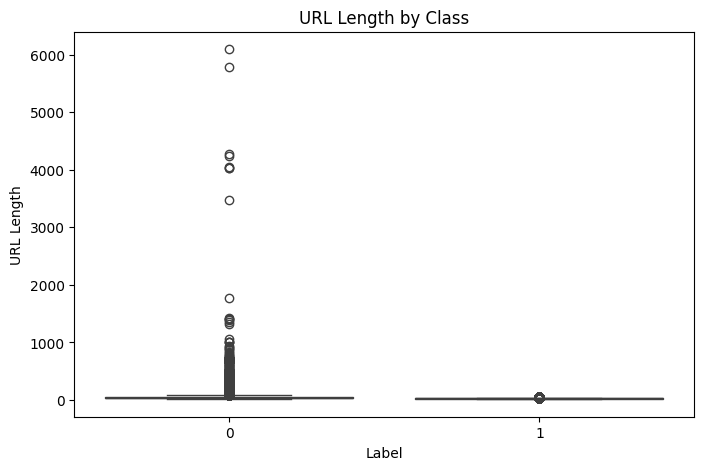

In [116]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="URLLength"
)

plt.title("URL Length by Class")
plt.xlabel("Label")
plt.ylabel("URL Length")
plt.show()

URLLength – Key Findings

Class 0 has a higher average URL length (45.70) compared with Class 1 (26.23).
The median URL length is also higher for Class 0 (34 vs. 26).
Class 0 shows considerably greater variability, with a standard deviation of 61.25.
Extreme URL-length outliers exist in Class 0, with a maximum value of 6,097 characters compared with 57 for Class 1.
The feature has a moderate negative correlation with the target (~-0.233).
URLLength is highly correlated with NoOfLettersInURL (~0.956), indicating significant feature redundancy.
Therefore, model development should evaluate whether both features are necessary and consider appropriate handling of extreme values.

In [117]:
df_clean.groupby("label")["DomainLength"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,24.44415,12.181599,4.0,16.0,22.0,29.0,110.0
1,134850.0,19.22861,4.815612,8.0,16.0,19.0,22.0,50.0


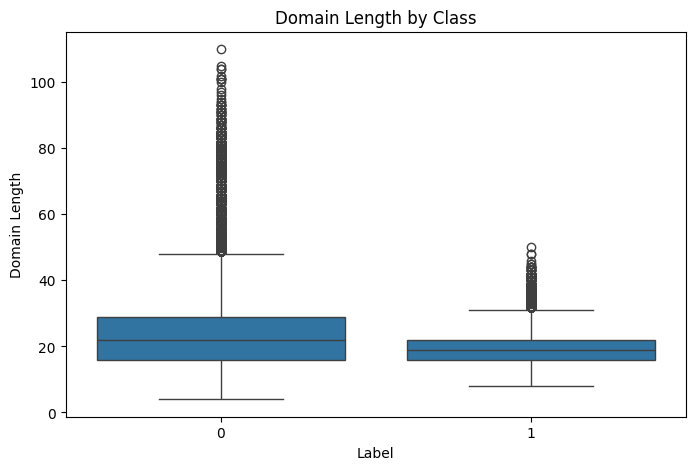

In [118]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="DomainLength"
)

plt.title("Domain Length by Class")
plt.xlabel("Label")
plt.ylabel("Domain Length")
plt.show()

DomainLength – Key Findings

Class 0 has a higher average domain length (24.44) compared with Class 1 (19.23).
The median is also higher for Class 0 (22 vs. 19), while Q3 is 29 vs. 22.
Class 0 shows considerably greater variability, with a standard deviation of 12.18 compared with 4.82 for Class 1.
The maximum domain length is 110 for Class 0 compared with 50 for Class 1.
The feature has a moderate negative correlation with the target (~-0.283).
Overall, DomainLength provides some class-level separation, but its relationship with the target is weaker than several other URL-based features.

In [119]:
remaining_features = [
    col for col in df_clean.columns
    if col not in [
        "FILENAME", "URL", "Domain", "TLD", "Title", "label"
    ]
]

remaining_features

['URLLength',
 'DomainLength',
 'IsDomainIP',
 'URLSimilarityIndex',
 'CharContinuationRate',
 'TLDLegitimateProb',
 'URLCharProb',
 'TLDLength',
 'NoOfSubDomain',
 'HasObfuscation',
 'NoOfObfuscatedChar',
 'ObfuscationRatio',
 'NoOfLettersInURL',
 'LetterRatioInURL',
 'NoOfDegitsInURL',
 'DegitRatioInURL',
 'NoOfEqualsInURL',
 'NoOfQMarkInURL',
 'NoOfAmpersandInURL',
 'NoOfOtherSpecialCharsInURL',
 'SpacialCharRatioInURL',
 'IsHTTPS',
 'LineOfCode',
 'LargestLineLength',
 'HasTitle',
 'DomainTitleMatchScore',
 'URLTitleMatchScore',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'NoOfPopup',
 'NoOfiFrame',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo',
 'NoOfImage',
 'NoOfCSS',
 'NoOfJS',
 'NoOfSelfRef',
 'NoOfEmptyRef',
 'NoOfExternalRef']

In [120]:
len(remaining_features), remaining_features

(50,
 ['URLLength',
  'DomainLength',
  'IsDomainIP',
  'URLSimilarityIndex',
  'CharContinuationRate',
  'TLDLegitimateProb',
  'URLCharProb',
  'TLDLength',
  'NoOfSubDomain',
  'HasObfuscation',
  'NoOfObfuscatedChar',
  'ObfuscationRatio',
  'NoOfLettersInURL',
  'LetterRatioInURL',
  'NoOfDegitsInURL',
  'DegitRatioInURL',
  'NoOfEqualsInURL',
  'NoOfQMarkInURL',
  'NoOfAmpersandInURL',
  'NoOfOtherSpecialCharsInURL',
  'SpacialCharRatioInURL',
  'IsHTTPS',
  'LineOfCode',
  'LargestLineLength',
  'HasTitle',
  'DomainTitleMatchScore',
  'URLTitleMatchScore',
  'HasFavicon',
  'Robots',
  'IsResponsive',
  'NoOfURLRedirect',
  'NoOfSelfRedirect',
  'HasDescription',
  'NoOfPopup',
  'NoOfiFrame',
  'HasExternalFormSubmit',
  'HasSocialNet',
  'HasSubmitButton',
  'HasHiddenFields',
  'HasPasswordField',
  'Bank',
  'Pay',
  'Crypto',
  'HasCopyrightInfo',
  'NoOfImage',
  'NoOfCSS',
  'NoOfJS',
  'NoOfSelfRef',
  'NoOfEmptyRef',
  'NoOfExternalRef'])

In [121]:
binary_features = [
    'IsDomainIP',
    'HasObfuscation',
    'IsHTTPS',
    'HasTitle',
    'HasFavicon',
    'Robots',
    'IsResponsive',
    'HasExternalFormSubmit',
    'HasSocialNet',
    'HasSubmitButton',
    'HasHiddenFields',
    'HasPasswordField',
    'Bank',
    'Pay',
    'Crypto',
    'HasCopyrightInfo'
]

binary_summary = (
    df_clean.groupby('label')[binary_features]
    .mean()
    .T * 100
)

binary_summary.columns = ['Class 0 (%)', 'Class 1 (%)']

binary_summary.sort_values(
    'Class 1 (%)',
    ascending=False
)

,Class 0 (%),Class 1 (%)
IsHTTPS,49.122563,100.000000
HasTitle,67.723836,99.875417
IsResponsive,31.704138,85.436411
HasCopyrightInfo,5.724234,80.823878
HasSocialNet,0.508357,79.455692
HasSubmitButton,8.439117,66.088246
HasHiddenFields,9.303621,59.078235
HasFavicon,8.740549,56.702262
Robots,6.579785,41.673712
Pay,6.000796,36.936596


Binary Feature Analysis – Key Findings

Several webpage-related binary features show substantial differences between the two target classes.
IsHTTPS, HasTitle, IsResponsive, HasCopyrightInfo, and HasSocialNet exhibit particularly large class-level differences.
HasSubmitButton, HasHiddenFields, and HasFavicon also show considerable separation between classes.
Pay and Bank indicators are more frequently observed in Class 1 than Class 0.
HasObfuscation and IsDomainIP occur rarely overall and are absent in Class 1, so their predictive contribution should be validated using model-based feature importance.
These results suggest that webpage structure, security indicators, and page metadata provide useful discriminatory information.
Binary feature frequency differences should be interpreted as dataset-level associations, not direct causal indicators of phishing or legitimacy.

In [122]:
corr_matrix = (
    df_clean
    .select_dtypes(include=["number"])
    .drop(columns="label")
    .corr()
    .abs()
)

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

high_corr[high_corr >= 0.80].head(30)

DomainTitleMatchScore  URLTitleMatchScore    0.961166
URLLength              NoOfLettersInURL      0.956046
                       NoOfDegitsInURL       0.835966
NoOfDegitsInURL        NoOfEqualsInURL       0.806379
dtype: float64

Multicollinearity / Feature Redundancy Findings

Only four feature pairs showed correlation ≥ 0.80, indicating that severe redundancy is limited to a small subset of features.
DomainTitleMatchScore and URLTitleMatchScore showed the highest correlation (0.961), suggesting substantial overlap in information.
URLLength and NoOfLettersInURL were also highly correlated (0.956).
URLLength–NoOfDegitsInURL (0.836) and NoOfDegitsInURL–NoOfEqualsInURL (0.806) showed high correlations.
Highly correlated features should not be removed solely based on correlation; model type, feature importance, validation performance, and interpretability should also be considered.
For the initial model, retaining the features and evaluating their contribution through feature importance/ablation is recommended.

In [123]:
feature_target_corr = (
    df_clean
    .select_dtypes(include=["number"])
    .corr()["label"]
    .drop("label")
    .abs()
    .sort_values(ascending=False)
)

feature_target_corr.head(20)

URLSimilarityIndex       0.860342
HasSocialNet             0.783882
HasCopyrightInfo         0.743197
HasDescription           0.690011
IsHTTPS                  0.610253
DomainTitleMatchScore    0.584204
HasSubmitButton          0.578816
IsResponsive             0.548977
URLTitleMatchScore       0.538844
SpacialCharRatioInURL    0.533003
HasHiddenFields          0.507715
HasFavicon               0.493607
URLCharProb              0.469521
CharContinuationRate     0.467162
HasTitle                 0.460337
DegitRatioInURL          0.431896
Robots                   0.392461
NoOfJS                   0.373162
LetterRatioInURL         0.366970
Pay                      0.359724
Name: label, dtype: float64

Feature Selection – Correlation-Based Findings

URLSimilarityIndex has the strongest absolute correlation with the target (0.860), making it the strongest candidate feature based on correlation analysis.
HasSocialNet (0.784), HasCopyrightInfo (0.743), and HasDescription (0.690) also show strong associations with the target.
IsHTTPS (0.610), DomainTitleMatchScore (0.584), HasSubmitButton (0.579), and IsResponsive (0.549) show moderate-to-strong relationships.
URL composition features such as SpacialCharRatioInURL, URLCharProb, CharContinuationRate, DegitRatioInURL, and LetterRatioInURL provide additional predictive signals.
DomainTitleMatchScore and URLTitleMatchScore have very high mutual correlation (~0.961), indicating substantial redundancy despite both having meaningful target correlations.
Correlation-based ranking should be treated as an initial screening method; final feature selection should be validated using model-based importance, cross-validation, and ablation analysis.

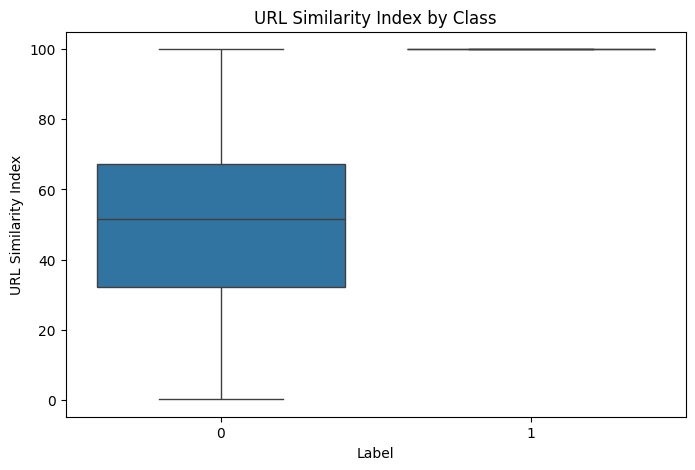

In [124]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="label",
    y="URLSimilarityIndex"
)

plt.title("URL Similarity Index by Class")
plt.xlabel("Label")
plt.ylabel("URL Similarity Index")

plt.show()

In [125]:
df_clean.groupby("label")["URLSimilarityIndex"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100520.0,49.651466,22.578566,0.155574,32.120613,51.478561,67.307692,100.0
1,134850.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.0


URLSimilarityIndex – Key Findings

URLSimilarityIndex shows the strongest target association among the analyzed features (absolute correlation ≈ 0.860).
Class 1 has a constant value of 100 for all observations, while Class 0 has a much broader distribution with a mean of 49.65 and standard deviation of 22.58.
The median for Class 0 is approximately 51.48, whereas the median for Class 1 is exactly 100.
The feature provides near-complete class separation in the observed dataset.
Because the feature exhibits an unusually perfect class-specific pattern, potential target leakage or dataset-construction bias should be investigated before using it in the final model.
The feature should therefore be retained as a candidate but explicitly validated for leakage before final model training.

In [126]:
df_clean.groupby("label")["URLSimilarityIndex"].agg(
    ["count", "nunique", "min", "max", "mean", "std"]
)

,count,nunique,min,max,mean,std
label,,,,,,
0,100520,36350,0.155574,100.0,49.651466,22.578566
1,134850,1,100.000000,100.0,100.000000,0.000000


In [127]:
pd.crosstab(
    df_clean["URLSimilarityIndex"] == 100,
    df_clean["label"],
    normalize="index"
) * 100

label,0,1
URLSimilarityIndex,,
False,100.000000,0.000000
True,0.579492,99.420508


URLSimilarityIndex – Leakage Investigation

The feature exhibits an extreme class-dependent pattern.
All 134,850 Class 1 observations have URLSimilarityIndex = 100.
Class 0 contains 36,350 unique values, ranging from approximately 0.156 to 100.
When URLSimilarityIndex = 100, 99.42% of observations belong to Class 1 and only 0.58% belong to Class 0.
When the value is below 100, all observations belong to Class 0.
This creates near-perfect separation between the two classes.
The feature should be treated as a potential leakage/dataset-construction bias candidate and investigated before final model training.
A model should ideally be evaluated both with and without this feature to determine whether it genuinely provides independent predictive information.

In [128]:
high_corr_pairs = high_corr[high_corr >= 0.80].reset_index()

high_corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_corr_pairs

,Feature_1,Feature_2,Correlation
0,DomainTitleMatchScore,URLTitleMatchScore,0.961166
1,URLLength,NoOfLettersInURL,0.956046
2,URLLength,NoOfDegitsInURL,0.835966
3,NoOfDegitsInURL,NoOfEqualsInURL,0.806379


In [129]:
top_features = feature_target_corr.head(20).reset_index()

top_features.columns = [
    "Feature",
    "Abs_Target_Correlation"
]

top_features

,Feature,Abs_Target_Correlation
0,URLSimilarityIndex,0.860342
1,HasSocialNet,0.783882
2,HasCopyrightInfo,0.743197
3,HasDescription,0.690011
4,IsHTTPS,0.610253
5,DomainTitleMatchScore,0.584204
6,HasSubmitButton,0.578816
7,IsResponsive,0.548977
8,URLTitleMatchScore,0.538844
9,SpacialCharRatioInURL,0.533003


In [130]:
top_features.to_csv(
    "top_20_features.csv",
    index=False
)

Final Feature Selection – EDA-Based Recommendation

Feature-target correlation identified URLSimilarityIndex, HasSocialNet, HasCopyrightInfo, HasDescription, and IsHTTPS as the strongest individual predictors.
A second group of features, including title matching, webpage structure, URL composition, and metadata features, showed moderate-to-strong associations and should initially be retained.
Lower-correlation features may still provide complementary information and should not be eliminated solely on the basis of univariate correlation.
Four highly correlated feature pairs were identified, with the strongest redundancy occurring between DomainTitleMatchScore–URLTitleMatchScore and URLLength–NoOfLettersInURL.
URLSimilarityIndex requires special investigation because of its near-perfect class separation and potential dataset-construction/target leakage.
Final feature selection should be based on model validation, feature importance, and ablation experiments rather than correlation alone.

In [131]:
class_counts = df_clean["label"].value_counts().sort_index()

class_percent = (
    df_clean["label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

,Count,Percentage
label,,
0,100520,42.707227
1,134850,57.292773


Class Distribution Findings

The dataset contains 235,370 observations.
Class 0 represents 42.71% of the dataset, while Class 1 represents 57.29%.
The dataset has a moderate class imbalance toward Class 1.
The imbalance is not severe enough to require immediate resampling solely based on class proportions.
Stratified train-test splitting should be used to preserve class proportions.
Model performance should be evaluated using multiple metrics, including Precision, Recall, F1-score and ROC-AUC, rather than accuracy alone.

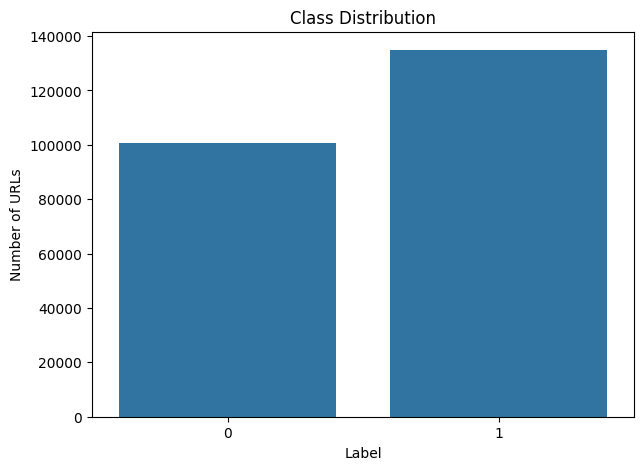

In [132]:
plt.figure(figsize=(7,5))

sns.countplot(data=df_clean, x="label")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of URLs")

plt.show()

In [133]:
# Check missing values
df_clean.isnull().sum().sort_values(ascending=False)

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [134]:
# Check duplicate rows
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [135]:
# Check duplicate URLs
print("Duplicate URLs:", df_clean["URL"].duplicated().sum())

Duplicate URLs: 0


In [136]:
df_clean.dtypes

FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode  

In [137]:
# Check unique values in categorical/text columns
text_cols = df_clean.select_dtypes(include="object").columns

for col in text_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")

FILENAME: 235370 unique values
URL: 235370 unique values
Domain: 220086 unique values
TLD: 695 unique values
Title: 197782 unique values


In [138]:
# Drop raw text columns
text_cols = ["FILENAME", "URL", "Domain", "TLD", "Title"]

df_model = df_clean.drop(columns=text_cols)

print("Original shape:", df_clean.shape)
print("Modeling shape:", df_model.shape)

Original shape: (235370, 56)
Modeling shape: (235370, 51)


In [139]:
X = df_model.drop(columns=["label"])
y = df_model["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235370, 50)
y shape: (235370,)


In [140]:
print("X columns:", X.columns.tolist())
print("Target unique values:", y.unique())

X columns: ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']
Target unique values: [1 0]


In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (188296, 50)
X_test : (47074, 50)
y_train: (188296,)
y_test : (47074,)


In [142]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64

Testing distribution:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


Train-Test Split

Dataset was divided into 80% training and 20% testing data.
Stratified splitting was used to preserve the original class distribution.
Both training and testing sets maintain the same class proportions: 42.71% Class 0 and 57.29% Class 1.
This ensures representative class distribution during model evaluation.

In [143]:
binary_cols = [
    col for col in X_train.columns
    if X_train[col].nunique() == 2
]

print("Binary columns:", len(binary_cols))
print(binary_cols)

Binary columns: 19
['IsDomainIP', 'HasObfuscation', 'IsHTTPS', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo']


In [144]:
continuous_cols = [
    col for col in X_train.columns
    if col not in binary_cols
]

print("Continuous/numeric columns:", len(continuous_cols))
print(continuous_cols)

Continuous/numeric columns: 31
['URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'LineOfCode', 'LargestLineLength', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'NoOfPopup', 'NoOfiFrame', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [145]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test_scaled[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (188296, 50)
X_test_scaled shape: (47074, 50)


In [146]:
X_train_scaled[continuous_cols].agg(["mean", "std"]).T.head(10)

,mean,std
URLLength,7.713118e-17,1.000003
DomainLength,-1.156968e-16,1.000003
URLSimilarityIndex,1.932053e-17,1.000003
CharContinuationRate,9.536494e-16,1.000003
TLDLegitimateProb,-1.890167e-16,1.000003
URLCharProb,1.543680e-15,1.000003
TLDLength,2.682799e-16,1.000003
NoOfSubDomain,-1.527152e-16,1.000003
NoOfObfuscatedChar,1.509417e-18,1.000003
ObfuscationRatio,1.079233e-17,1.000003


In [147]:
X_train_scaled[binary_cols].head()

,IsDomainIP,HasObfuscation,IsHTTPS,HasTitle,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo
68038,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
231228,0,0,1,1,1,0,1,0,0,1,0,1,1,1,0,0,0,0,1
230792,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
73306,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
9650,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0


Feature Scaling

19 binary features were identified and retained in their original 0/1 representation.
31 continuous numerical features with different scales were standardized using StandardScaler.
The scaler was fitted exclusively on the training data and subsequently applied to the test data.
This prevents information leakage from the test set and ensures appropriately scaled numerical inputs for scale-sensitive models.

In [148]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nMissing values in train:",
      X_train_scaled.isnull().sum().sum())

print("Missing values in test:",
      X_test_scaled.isnull().sum().sum())

Train shape: (188296, 50)
Test shape: (47074, 50)

Missing values in train: 0
Missing values in test: 0


In [149]:
print("\nScaled feature means:")
print(X_train_scaled[continuous_cols].mean().round(4).head(10))

print("\nScaled feature std:")
print(X_train_scaled[continuous_cols].std().round(4).head(10))


Scaled feature means:
URLLength               0.0
DomainLength           -0.0
URLSimilarityIndex      0.0
CharContinuationRate    0.0
TLDLegitimateProb      -0.0
URLCharProb             0.0
TLDLength               0.0
NoOfSubDomain          -0.0
NoOfObfuscatedChar      0.0
ObfuscationRatio        0.0
dtype: float64

Scaled feature std:
URLLength               1.0
DomainLength            1.0
URLSimilarityIndex      1.0
CharContinuationRate    1.0
TLDLegitimateProb       1.0
URLCharProb             1.0
TLDLength               1.0
NoOfSubDomain           1.0
NoOfObfuscatedChar      1.0
ObfuscationRatio        1.0
dtype: float64


Preprocessing Validation

The final modeling dataset contains 50 numerical features and 235,370 observations. The data was split into 188,296 training samples and 47,074 testing samples using stratified sampling. No missing values or duplicate records were present. Nineteen binary features were retained in their original 0/1 representation, while 31 continuous numerical features were standardized using StandardScaler. The scaler was fitted only on the training set and then applied to the test set, preventing data leakage. Post-scaling validation confirmed approximately zero mean and unit standard deviation for the continuous training features.

In [150]:
top_features = [
    "URLSimilarityIndex",
    "HasSocialNet",
    "HasCopyrightInfo",
    "HasDescription",
    "IsHTTPS",
    "DomainTitleMatchScore",
    "HasSubmitButton",
    "IsResponsive",
    "URLTitleMatchScore",
    "SpacialCharRatioInURL"
]

print(top_features)

['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton', 'IsResponsive', 'URLTitleMatchScore', 'SpacialCharRatioInURL']


In [151]:
top_continuous_features = [
    f for f in top_features
    if f in continuous_cols
]

print(top_continuous_features)

['URLSimilarityIndex', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'SpacialCharRatioInURL']


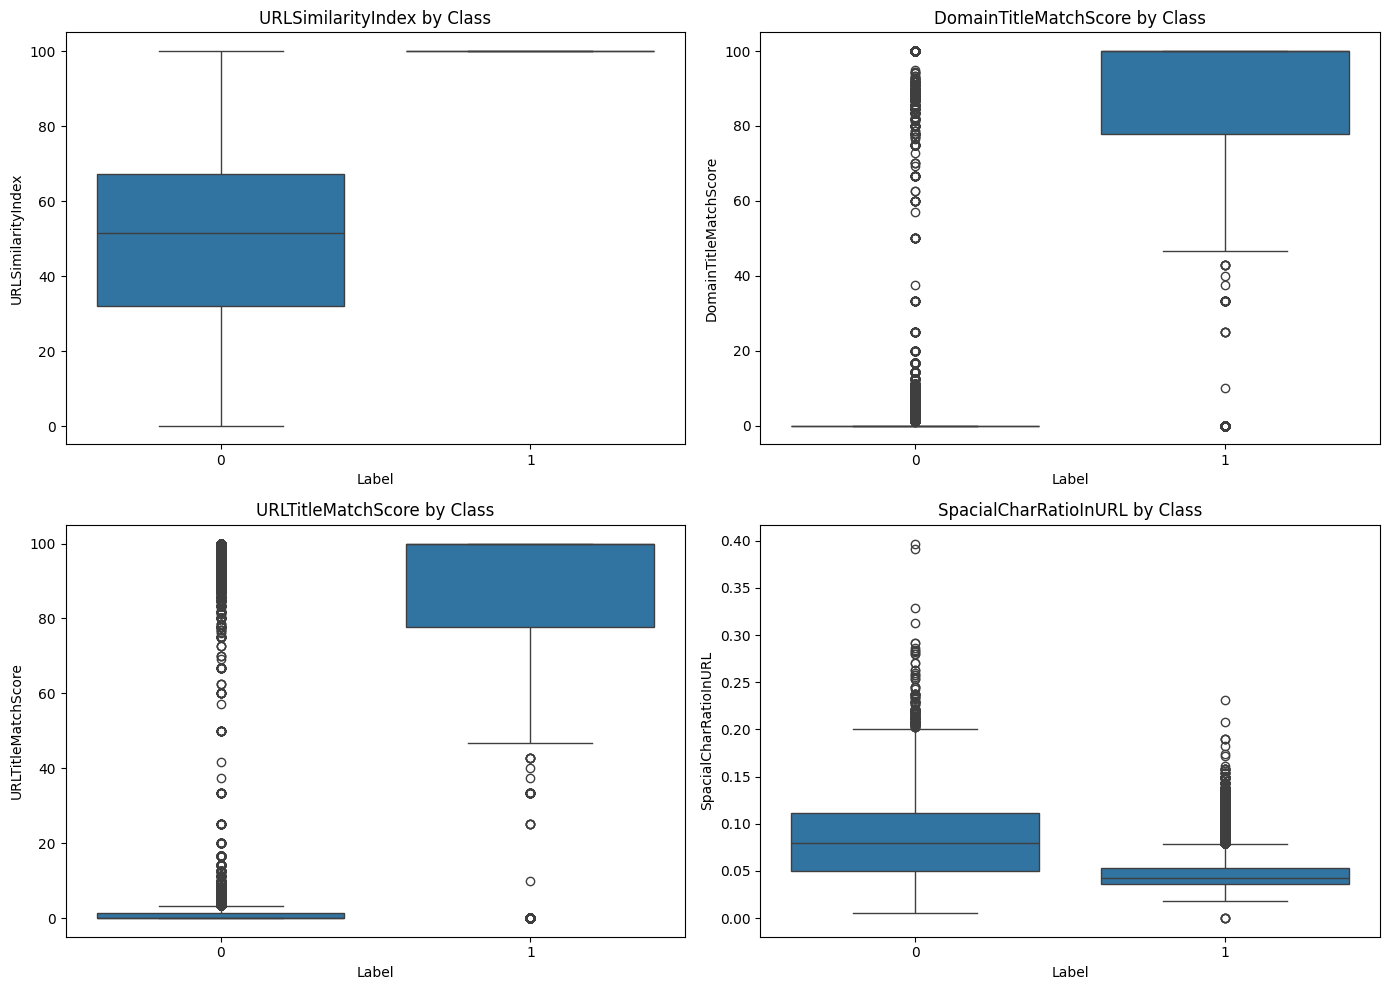

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), top_continuous_features):
    sns.boxplot(
        data=df_clean,
        x="label",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Class")
    ax.set_xlabel("Label")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

<Figure size 1400x900 with 0 Axes>

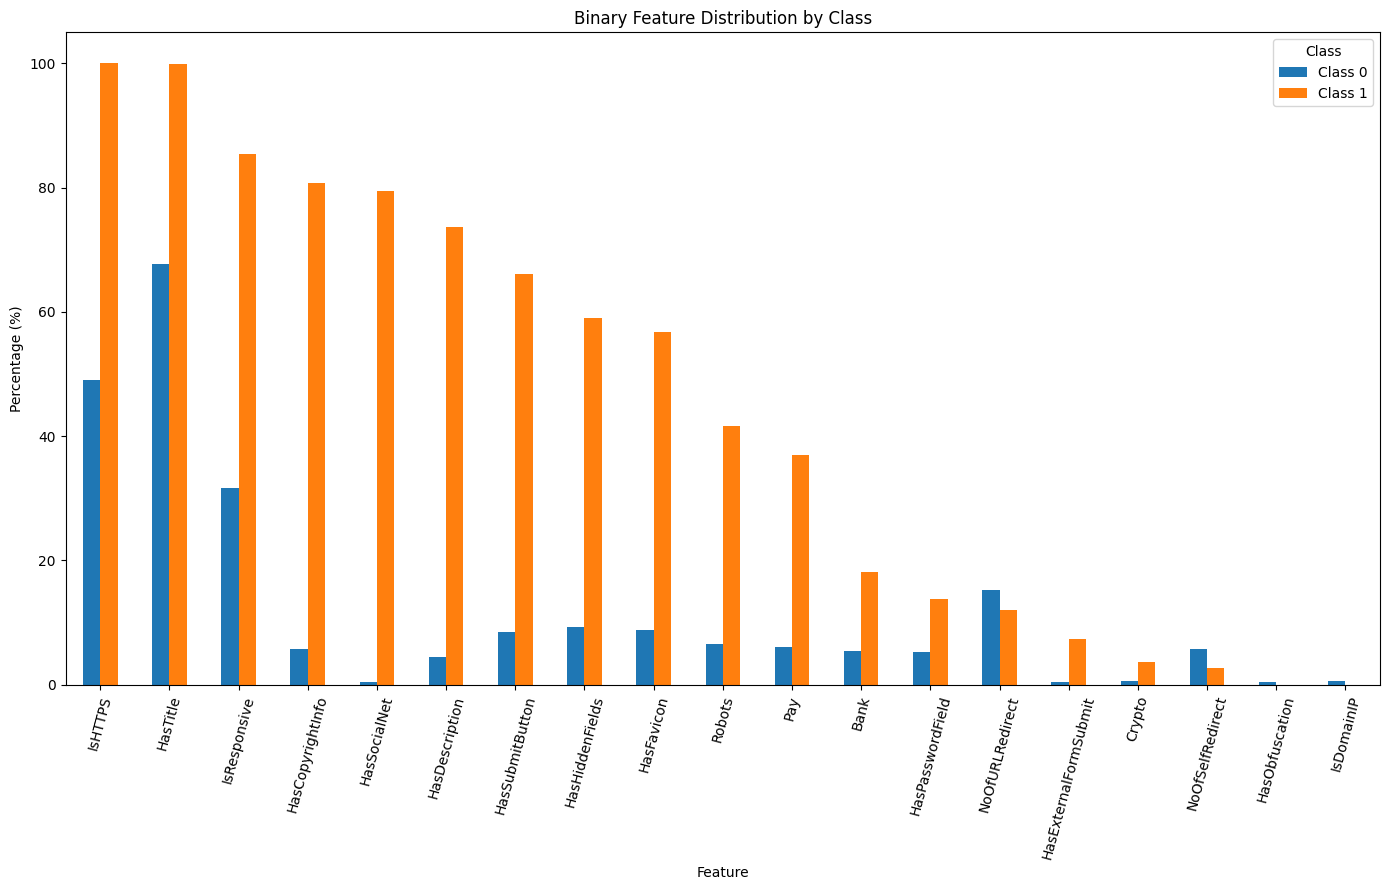

In [153]:
binary_class_pct = (
    df_clean.groupby("label")[binary_cols]
    .mean()
    .T * 100
)

binary_class_pct.columns = ["Class 0", "Class 1"]

binary_class_pct = binary_class_pct.sort_values(
    "Class 1",
    ascending=False
)

plt.figure(figsize=(14, 9))

binary_class_pct.plot(
    kind="bar",
    figsize=(14, 9)
)

plt.title("Binary Feature Distribution by Class")
plt.xlabel("Feature")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=75)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [155]:
target_corr = (
    df_clean.select_dtypes(include="number")
    .corr()["label"]
    .drop("label")
)

print(target_corr.abs().sort_values(ascending=False).head(20))

URLSimilarityIndex       0.860342
HasSocialNet             0.783882
HasCopyrightInfo         0.743197
HasDescription           0.690011
IsHTTPS                  0.610253
DomainTitleMatchScore    0.584204
HasSubmitButton          0.578816
IsResponsive             0.548977
URLTitleMatchScore       0.538844
SpacialCharRatioInURL    0.533003
HasHiddenFields          0.507715
HasFavicon               0.493607
URLCharProb              0.469521
CharContinuationRate     0.467162
HasTitle                 0.460337
DegitRatioInURL          0.431896
Robots                   0.392461
NoOfJS                   0.373162
LetterRatioInURL         0.366970
Pay                      0.359724
Name: label, dtype: float64


In [156]:
top20_features = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print(top20_features)

['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton', 'IsResponsive', 'URLTitleMatchScore', 'SpacialCharRatioInURL', 'HasHiddenFields', 'HasFavicon', 'URLCharProb', 'CharContinuationRate', 'HasTitle', 'DegitRatioInURL', 'Robots', 'NoOfJS', 'LetterRatioInURL', 'Pay']


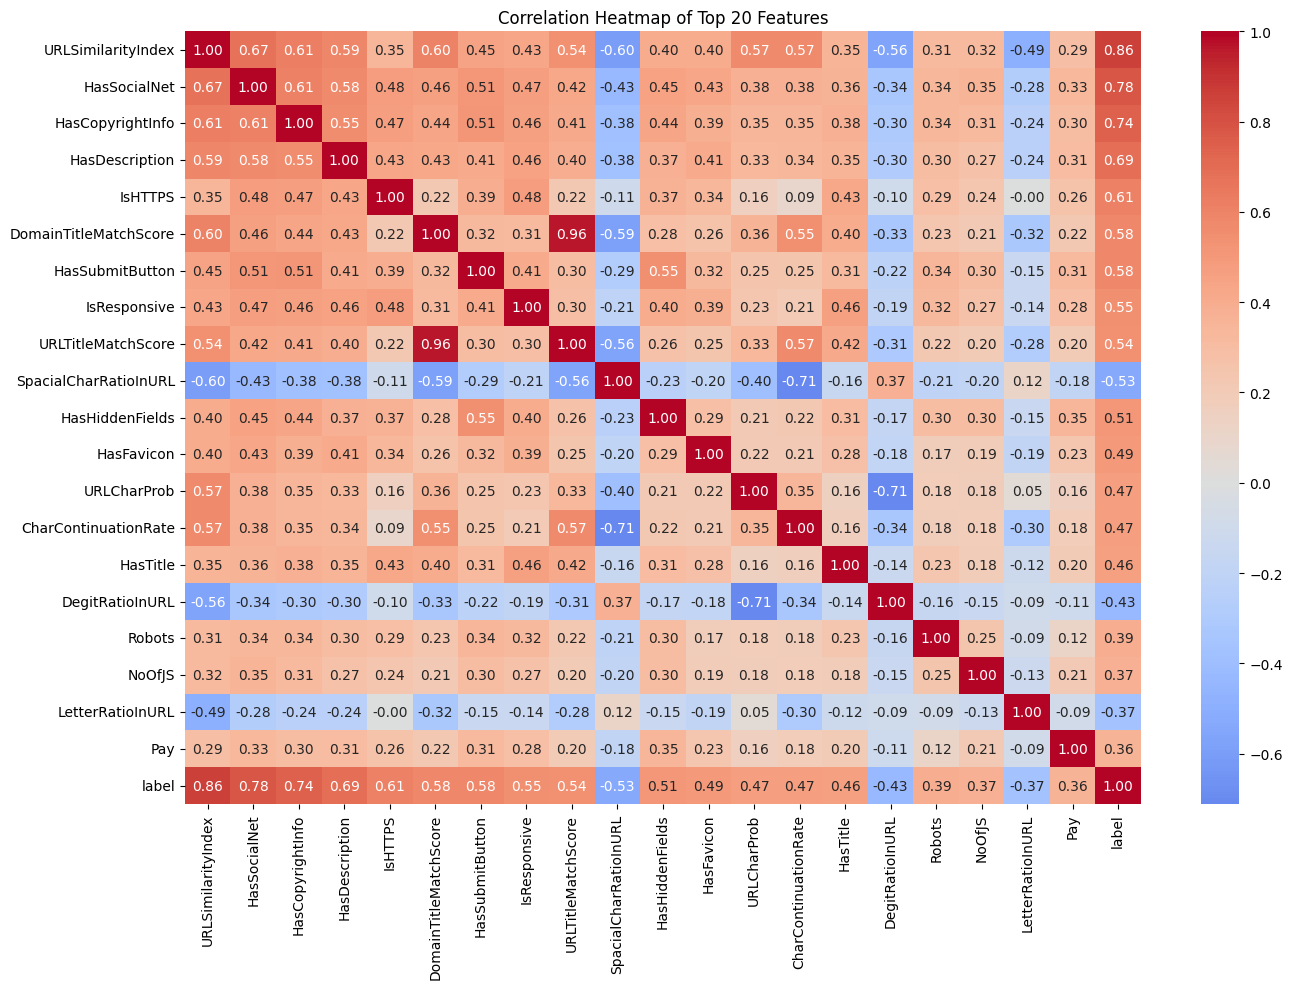

In [157]:
plt.figure(figsize=(14, 10))

corr_matrix = df_clean[top20_features + ["label"]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Top 20 Features")
plt.tight_layout()
plt.show()

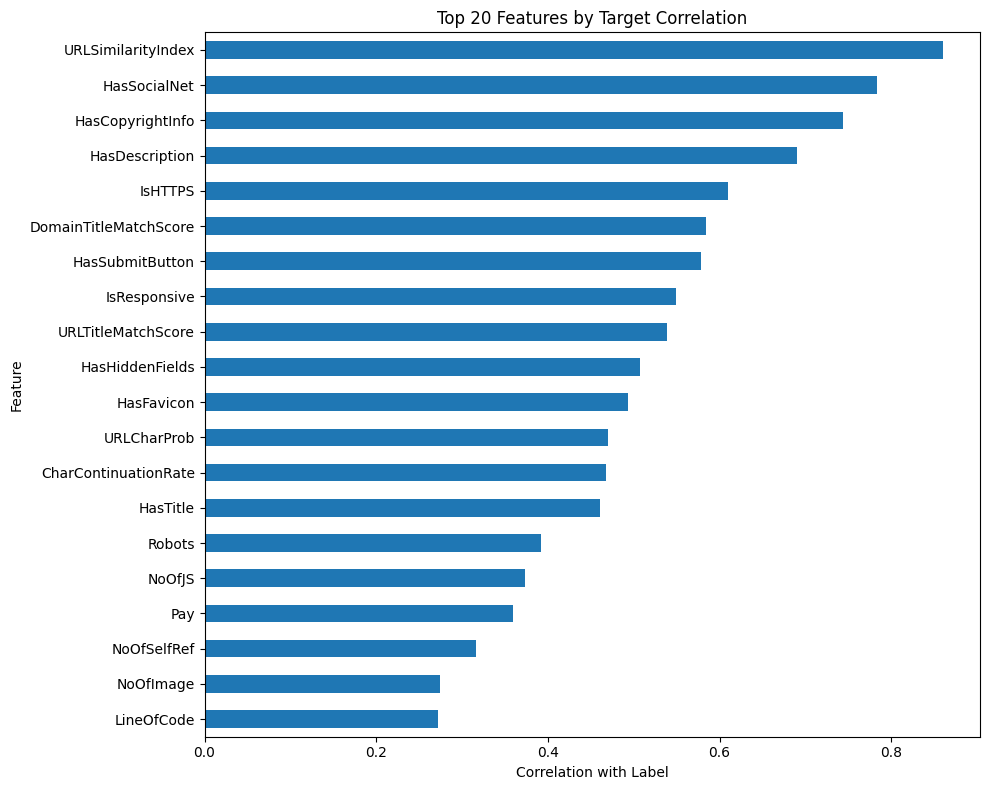

In [158]:
target_corr_sorted = (
    target_corr
    .sort_values()
)

plt.figure(figsize=(10, 8))

target_corr_sorted.tail(20).plot(
    kind="barh"
)

plt.title("Top 20 Features by Target Correlation")
plt.xlabel("Correlation with Label")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

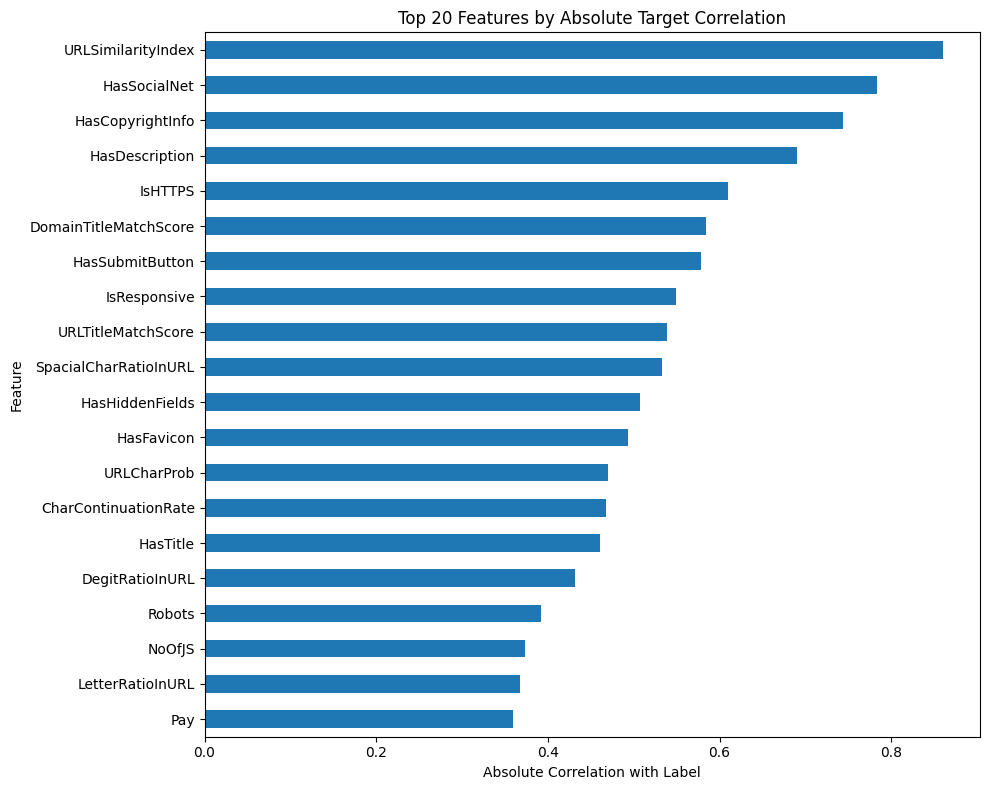

In [159]:
top20_abs_corr = (
    target_corr.abs()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

top20_abs_corr.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Features by Absolute Target Correlation")
plt.xlabel("Absolute Correlation with Label")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()